<img src=../figures/Brown_logo.svg width=50%>

## Agentic Data-Driven Design & Analysis of Structures & Materials

## From human-centric to agentic-centric data-driven design

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor, Brown University

### Elvis Aguero | <a href = "mailto: elvis_vera@brown.edu">elvis_vera@brown.edu</a>  | PhD candidate, Brown University

## **OPTION 1**. Run this notebook **locally in your computer** (needed for the agentic part)

1. Install [mamba](https://mamba.readthedocs.io/en/latest/installation/mamba-installation.html) (or conda) and [git](https://github.com/git-guides/install-git). Clone the course repository:
```
git clone https://github.com/bessagroup/3dasm_course
```

2. Create the environment for this short course (Python 3.11, JupyterLab 4 with the RISE slideshow extension, and f3dasm):
```
mamba create -n aescape_course python=3.11 jupyterlab=4 numpy scipy matplotlib pandas scikit-learn ipykernel ipywidgets requests
mamba activate aescape_course
pip install jupyterlab-rise "f3dasm[scipy]==2.4.0"
```

3. Install a coding agent. The agentic stages of Part 1 were run with [Claude Code](https://docs.anthropic.com/en/docs/claude-code), which needs a Claude subscription:
```
curl -fsSL https://claude.ai/install.sh | bash
claude
```
Log in once. Check it works with `claude -p "say ok"`.

4. Start JupyterLab from the `3dasm_course` folder and open `Lectures/short_course/aescape_course.ipynb`:
```
jupyter lab
```
To see the slides, press `Alt+R` (or the RISE button in the notebook toolbar). The slide fonts are small by default: zoom the browser to 150 to 175% with `Ctrl` and `+` before going full screen.

5. **With a Claude subscription**, run the notebook top to bottom. It builds all three demo folders from scratch and really calls the agent: seconds for demo 1, a few minutes for each prompt of demo 2, and demo 3 can take ten. Nothing is shipped with the repository, so what you get is your own run, not mine.

6. **Without one, read this notebook rather than running it.** Demo 1 works without an agent, but running any cell clears the stored outputs, and those outputs are the only record of what the agents did on my machine. The second code cell checks for a working Claude Code and says so before you get that far. If you run it by accident: `git checkout Lectures/short_course/aescape_course.ipynb`.


## **OPTION 2**. Use **Google's Colab** (no installation, but only for the code cells of this notebook)

1. Go to https://colab.research.google.com and log in.
2. File > Open notebook > GitHub, paste https://github.com/bessagroup/3dasm_course, open `Lectures/short_course/aescape_course.ipynb`.
3. Run this first, in a new cell at the top. The notebook reads a dataset and the slide figures out of the repository, so Colab needs a copy of it:
```
!git clone https://github.com/bessagroup/3dasm_course
%cd 3dasm_course/Lectures/short_course
```
4. The code cells install `f3dasm` on first run. The agent prompts cannot run in Colab: they need a coding agent on your own machine (Option 1). You will see the committed runs instead.


In [1]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!

plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

# To limit the number of rows to show in a dataframe, for presentation purposes:
import pandas as pd

pd.set_option('display.max_rows', 10)

In [2]:
# Colab (or any machine without f3dasm): install it on first run, about 20 seconds.
try:
    import f3dasm
except ModuleNotFoundError:
    %pip install "f3dasm[scipy]==2.4.0" --quiet
    import f3dasm

from f3dasm import ExperimentData, datagenerator, create_sampler, Block
from f3dasm.design import Domain


In [3]:
# Can this notebook run its agent prompts? Asked once, here, so nobody finds out
# forty cells later. `claude -p "say ok"` costs a token and answers in a second.
import shutil, subprocess

CLAUDE = shutil.which("claude")
if CLAUDE:
    try:
        logged_in = subprocess.run([CLAUDE, "-p", "say ok"], capture_output=True,
                                   text=True, timeout=120).returncode == 0
    except subprocess.TimeoutExpired:
        logged_in = False
    CLAUDE = CLAUDE if logged_in else None

if CLAUDE:
    print("Claude Code is installed and logged in: every demo in this notebook will run.")
else:
    print("""
NO WORKING CLAUDE CODE  --  READ THIS NOTEBOOK, DO NOT RUN IT

  Demo 1, the human-centric study, runs fine without it. The agent prompts of
  demos 2 and 3 cannot run, and running this notebook CLEARS the stored outputs
  that are the only record of what those agents did.

  To fix it : install Claude Code, then check with   claude -p "say ok"
  To recover: git checkout Lectures/short_course/aescape_course.ipynb
""".strip())

Claude Code is installed and logged in: every demo in this notebook will run.


# Part 1. From human-centric to agentic-centric data-driven processes

## The smallest problem I teach

A car at velocity $x$ stops after a distance $y$. The driver's reaction time $z$ is random.

$y = z\,x + 0.1\,x^2, \qquad z \sim \mathcal{N}(1.5,\ 0.5^2)$

<img src=../figures/reaction-braking-stopping.svg width=42% align="left">

We do not know this equation. We only get to measure the stopping distance. Our task: predict $y$ for a new $x$, with honest uncertainty.

This is the first problem in my course because it is simple. You will see the entire data-driven process on it, first done by a person, then done by agents, and you will be able to judge every step because you can do the algebra in your head. The **true answer**, which the process does not know, is that **the mean is *quadratic* in velocity** and **the noise grows *linearly* with velocity**.

## The data-driven process

<p align="center"><img src=../figures/data-driven-process.png width=50%></p>

Four stages, closed into a cycle: **design of experiments** (a.k.a. sampling), **data generation**, **machine learning**, **optimization**. Every engineering study we run follows this loop, although you can skip some modules. For example, you could already have a dataset (no design of experiments and no data generation modules), and you may want to only learn a model from that data (no optimization module), which would mean that you only need to define the "machine learning" module.

The user (human) decides what goes in each module (each box). The software runs the boxes.

This figure summarizes most data-driven processes. When solving a real problem, each of these boxes need to be defined. In the recent past, a person filled all the content in all four modules. Today you will see agents fill two of them on the "car stopping distance" toy problem, and in Part 2, all four on a real problem.

## A simple data-driven process for the car stopping distance problem

<p align="center"><img src=../figures/f3dasm_carstoppingdistance_line.svg width=85%></p>

We have our own software: **f**ramework for **d**ata-**d**riven **d**esign and **a**nalysis of **s**tructures and **m**aterials (`f3dasm`).

- In `f3dasm`, the input space is a `Domain` and it is obtained from the **Design of Experiments** module.
- Each input sample `x` goes into the **Data generation** module to obtain the output `y`, which becomes a row in the `ExperimentData` record.
- Then, we can define a **Machine learning** module to learn a model that is trained on the generated dataset, or we can define an **Optimization** module that tries to find the optimum by drawing a new sample and generate an output from the data generation module. 
- Each module in the data-driven process is a `Block` that reads the record and writes to it. The record lives on disk as plain files.

In the past, a person would write each module. Let's illustrate this using `f3dasm` to create data for the "car stopping distance" example, i.e., simulating a real experiment from which we collect the stopping distance from different drivers.

This involves 2 modules in the data-driven process: **design of experiments** (sampling), and **data generation**.

Let's start by defining the **Design of experiments** (or Sampling) `Block`:

In [4]:
# This is the code that a human would write to define the "car stopping distance" Design of experiments.
# For example, we can define the input space of car velocities and draw 60 of them at random.
import numpy as np
from f3dasm import ExperimentData, create_sampler, datagenerator
from f3dasm.design import Domain

X_LOW, X_HIGH = 3.0, 83.0     # velocity range [m/s]
MU_Z, SD_Z = 1.5, 0.5         # reaction time z ~ N(1.5, 0.5^2)
N_DEMO = 60                   # this illustration only. The dataset we load next was
SEED_DEMO = 1                 # made separately: a Sobol design, 50 stops, other seeds
SEED_DEMO_NOISE = 11

demo_domain = Domain()
demo_domain.add_float("x", low=X_LOW, high=X_HIGH)

simulated = ExperimentData(domain=demo_domain)
sampler = create_sampler("random_sampler", seed=SEED_DEMO)
simulated = sampler.call(simulated, n_samples=N_DEMO)
demo_domain

Domain(input_space={'x': ContinuousParameter(lower_bound=3.0, upper_bound=83.0, log=False)}, output_space={})

**Note**: Here we decided to use random sampling for our design of experiments. Instead, we could have used a **space-filling** sampler  that would cover the range more evenly for the same number of runs, and `f3dasm` has one built in: `create_sampler("sobol_sampler")`. The dataset we load next was made that way, and on this problem the difference is not cosmetic.

**Additional note**: Sampling can have a significant difference in the quality of the model that is eventually trained by the machine learning module. For example, if we used a space-filling sampler like **Sobol sequences** to obtain a dataset of 50 velocities, and then we compared with 200 different datasets obtained by ramdom sampling of 50 velocities, the machine learning models that we obtained would be better for the Sobol sequence sampling. We tested this for the simple linear regression model that we will show in the next cells and it was better with Sobol sequence sampling in more than 85% of those 200 randomly drawn datasets.

And now we define the **Data generation** `Block`, i.e., the simulator of the cars being driven at a given velocity and stopping:

In [5]:
# The Data generation of this example is obtained by simulating an experiment: one draw of the reaction
# time of a driver per experiment, then calculating the stopping distance.
rng = np.random.default_rng(SEED_DEMO_NOISE)

@datagenerator(output_names=["y"]) # define the data generation module, whose output y is the stopping distance
def car(x: float) -> float:
    z = rng.normal(MU_Z, SD_Z) # draw a reaction time from the driver
    return float(z * x + 0.1 * x ** 2) # calculate the stopping distance (this assumes that we knew the ground-truth)

simulated = car.call(simulated, mode="sequential")   # 60 stops, in memory only

sim_in, sim_out = simulated.to_pandas()
print(sim_in.join(sim_out)[["x", "y"]].head())   # x and y: all this stage produced

           x           y
0  43.945730  259.792626
1  79.037096  796.977142
2  14.532769   51.818585
3  78.891956  720.602441
4  27.946516  115.856946


We defined a simple `Block` for Data generation. However, a more complex Data generation process could have been defined. For example, it could be an FEM or IGA simulation of a physical phenomenon of interest.

## Demo 1: Human-centric use of f3dasm for the car stopping distance problem

So far we **illustrated** the simplest data-driven process: how to generate data with `f3dasm` when you own the simulator (data generation) and define the sampling (design of experiments). Those 60 samples of drivers stopping stayed in memory and were never written anywhere.

A real example often starts with an existing dataset. So from here on we **load `data/car_stopping_distance`**.

- This dataset was obtained from the same car problem, simulated once from the same equation and saved
- It contains **50 samples (50 drivers stopping) rather than the 60 we just made**
- It was obtained using a different Design of Experiments strategy: sampling was done from a **Sobol sequence** instead of samping at random like we did in the previous cell.

Until this point in the notebook, I showcased the simplest data-driven process: design of experiments (sampling) + data generation, ran it and obtained a dataset. Often, a dataset is already handed to you from someone else who ran an experiment. That's what we will assume from this point onwards. If somebody asks how to get their own spreadsheet into f3dasm rather than a record somebody already stored, it is one line: `ExperimentData(domain=domain, input_data=df[['x']], output_data=df[['y']])`, and then `.store()` it once.

In [6]:
# The 50 measured stops, as handed to us. f3dasm can read the dataset as follows:
# `simulated` above was the illustration, and we now drop it. From here to the end
# of Part 1, `data` is the record we were handed and nothing else.
data = ExperimentData.from_file("data/car_stopping_distance")

input_df, output_df = data.to_pandas()
print(f"{len(data)} stops, x in [{input_df['x'].min():.2f}, {input_df['x'].max():.2f}], "
      f"domain {data.domain.input_space['x'].lower_bound} to {data.domain.input_space['x'].upper_bound}")

50 stops, x in [3.00, 81.75], domain 3.0 to 83.0


Now that we loaded the dataset given by someone else, our goal is simple:

- Create a model that learns from that data so that you can make predictions.

In other words, you only need to build the **Machine learning** module, read the data and train an ML model.

- Without using any AI agents, you have to decide what is the ML model you want. For example: Quadratic least squares and constant noise.
- Let's assume you want to use `scikit-learn` to define this linear regression model inside our ML module.

In [7]:
# Machine learning module defined by a human: the third block of the process.
from f3dasm import Block
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

class QuadraticLeastSquares(Block):
    """A person decided: degree-2 least squares for the mean, one constant noise sd."""
    degree = 2

    def call(self, data, **kwargs):
        input_df, output_df = data.to_pandas()
        x = input_df["x"].to_numpy(dtype=float).reshape(-1, 1)
        y = output_df["y"].to_numpy(dtype=float)

        model = make_pipeline(                                       # features [1, x, x^2]
            PolynomialFeatures(degree=self.degree, include_bias=True),
            LinearRegression(fit_intercept=False))                   # least squares
        model.fit(x, y)
        resid = y - model.predict(x)
        sd_const = float(np.sqrt(resid @ resid / (len(y) - self.degree - 1))) # calculate constant noise from residual
        self.coef, self.sd_const = model[-1].coef_, sd_const
        print(f"coefficients [1, x, x^2] = {np.array2string(self.coef, precision=4)}")
        print(f"constant residual sd     = {sd_const:.4f}")

        # f3dasm bookkeeping: reopen the rows, append the new columns
        @datagenerator(output_names=["y_pred_baseline", "sd_baseline", "_source_baseline"])
        def predict(x: float):
            return float(model.predict([[x]])[0]), sd_const, "baseline"

        return predict.call(data.mark_all("open"), mode="sequential")


We can now run the "data-driven process" (it's only the ML module in this case...):

1. Read the data: done on a previous slide. Somebody else observed many drivers stopping to avoid hitting the moose.
2. Choose a simple machine learning model: done on the last slide (a Quadratic Least Squares model with constant noise).
3. Train the model and store the updated data object (see code below)

In [8]:
from pathlib import Path
DEMO1 = Path("demo1_car_no_agents")   # the study folder, created here because this
                                      # is the first moment there is anything to keep

data = QuadraticLeastSquares().call(data)   # trains, and writes its predictions into the record
data.store(DEMO1 / "data")                  # demo1_car_no_agents/data

coefficients [1, x, x^2] = [-0.6562  1.4464  0.1004]
constant residual sd     = 29.9218


This shows that we trained the model on the data.

We can now make predictions for unseen drivers. Very simple.

Now that the data-driven process ran, we can plot the results (code is hidden in the notes below):

In [9]:
# PLOTTING HELPER. Not part of the data-driven process.
# The dashed band is the GROUND TRUTH: we know it because the dataset we loaded was simulated
# from the equation on the first slide (in practice, we don't know the ground-truth, of course!).
# The process never sees it; it is drawn here only for us to visually judge the quality of our model.
def true_mean(x):
    return MU_Z * np.asarray(x) + 0.1 * np.asarray(x) ** 2

def true_sd(x):
    return SD_Z * np.asarray(x)

def plot_fit(data, mean_col, sd_col, title):
    input_df, output_df = data.to_pandas()
    x = input_df["x"].to_numpy(dtype=float); y = output_df["y"].to_numpy(dtype=float)
    order = np.argsort(x)
    mean = output_df[mean_col].to_numpy(dtype=float)[order]
    sd = output_df[sd_col].to_numpy(dtype=float)[order]
    grid = np.linspace(X_LOW, X_HIGH, 400)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(x, y, s=18, color="#333333", zorder=3, label="training data")
    ax.plot(x[order], mean, color="#1f77b4", lw=2, label="model mean")
    ax.fill_between(x[order], mean - 2 * sd, mean + 2 * sd, color="#1f77b4", alpha=0.20,
                    label="model $\\pm2$ sd")
    ax.plot(grid, true_mean(grid) + 2 * true_sd(grid), "k--", lw=1.4, label="GROUND TRUTH $\\pm2$ sd (sd = 0.5 x)")
    ax.plot(grid, true_mean(grid) - 2 * true_sd(grid), "k--", lw=1.4)
    ax.set_xlabel("speed x [m/s]"); ax.set_ylabel("stopping distance y [m]"); ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    return fig


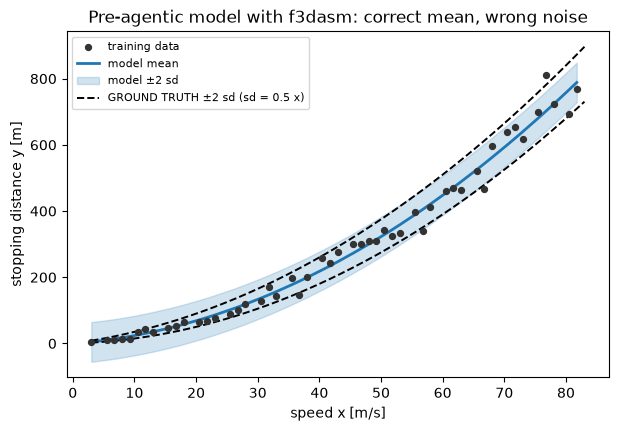

In [10]:
plot_fit(data, "y_pred_baseline", "sd_baseline", "Pre-agentic model with f3dasm: correct mean, wrong noise");


**Conclusion**: Good mean. Wrong uncertainty. The true band fans out with velocity; the model's band does not.

This is what a competent engineer writes in ten minutes, and it is wrong in the way that matters if you are certifying a braking system: the uncertainty at highway speed is badly underestimated. Every decision that produced this plot was ours: the model class (we got it right), the noise assumption (we got it wrong).

### The record, now that the model has run

In [11]:
data = ExperimentData.from_file(DEMO1 / "data")   # read back from disk, not from memory
input_df, output_df = data.to_pandas()
print(input_df.join(output_df).head(3).to_string())

      x           y  y_pred_baseline  sd_baseline _source_baseline
0   3.0    5.231400         4.586514    29.921787         baseline
1  43.0  277.273153       247.157055    29.921787         baseline
2  63.0  462.585642       488.908090    29.921787         baseline


Every row contains a sample of the experiment (x, and y). We also added the model outputs and the model name, `_source_baseline`. Stamping *who wrote* each column is a habit, not something `f3dasm` requires. It is also the one habit that will matter most in a minute, when somebody other than me starts writing into this file. **The file we save on disk is keeping a record of what we are doing in this notebook.**

### The files a human-centric study leaves behind

Everything you have just watched, as files on disk:

```
demo1_car_no_agents/
  data/          the 50 measured stops you were handed, plus what your model added
  baseline.py    everything you wrote in this notebook, in one file
```

**That is the whole study.** `baseline.py` is the code we wrote in this notebook for the machine learning block and for plotting, collected into one file: no sampler and no data generator, because the data was handed to us.

One thing it does **not** draw: the true band. We drew it because we happen to know it. A real study does not.

The **Notes** below run `baseline.py`, so you can see it makes the same figure.

In [12]:
# This cell writes baseline.py: the f3dasm machine learning module we defined above,
# plus the figure, collected into the one file a human-centric study leaves behind.
BASELINE_PY = r'''
"""The human-centric baseline: a person decided everything.

This is the **machine learning** module of the data-driven process, plus the
figure, collected into one file. Run it inside a folder that holds the record:

    python baseline.py

It reads `data/`, fits the model a person chose, writes the fit back into the
record as new columns, and draws the result. There is no sampler and no data
generator here, because the measurements were handed to us.

The two decisions a person made, and nothing in this file examines either:

    the mean  is a degree-2 polynomial in x
    the noise is ONE constant standard deviation, the same at every speed

Note what is NOT plotted: the true band. In the notebook we drew it because we
happen to know it. In a study you do not, which is why the figure below can
only show the model's own claim about its uncertainty, never whether it is right.
"""

from __future__ import annotations

from pathlib import Path

import matplotlib

matplotlib.use("Agg")          # a script writes files; it never opens a window

import matplotlib.pyplot as plt
import numpy as np
from f3dasm import Block, ExperimentData, datagenerator
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

DEGREE = 2
RECORD = "data"
FIGURE = Path("figures/baseline.png")


class QuadraticLeastSquares(Block):
    """Degree-2 least squares for the mean, one constant sd for the noise.

    Reads the record, writes `y_pred_baseline`, `sd_baseline` and the provenance
    stamp `_source_baseline` back into it.
    """

    degree = DEGREE

    def call(self, data: ExperimentData, **kwargs) -> ExperimentData:
        input_df, output_df = data.to_pandas()
        x = input_df["x"].to_numpy(dtype=float).reshape(-1, 1)
        y = output_df["y"].to_numpy(dtype=float)

        model = make_pipeline(                                   # features [1, x, x^2]
            PolynomialFeatures(degree=self.degree, include_bias=True),
            LinearRegression(fit_intercept=False),               # least squares
        )
        model.fit(x, y)
        resid = y - model.predict(x)
        sd_const = float(np.sqrt(resid @ resid / (len(y) - self.degree - 1)))
        self.coef, self.sd_const = model[-1].coef_, sd_const

        print("  fitted by least squares:")
        print(f"    coefficients [1, x, x^2] = "
              f"{np.array2string(self.coef, precision=4)}")
        print(f"    constant residual sd     = {sd_const:.4f} m")
        print(f"    train RMSE               = {np.sqrt(np.mean(resid ** 2)):.4f} m")

        # f3dasm bookkeeping: reopen the rows, append the new columns
        @datagenerator(output_names=["y_pred_baseline", "sd_baseline",
                                     "_source_baseline"])
        def predict(x: float):
            return float(model.predict([[x]])[0]), sd_const, "baseline"

        return predict.call(data.mark_all("open"), mode="sequential")


def plot(data: ExperimentData, coef, sd_const) -> Path:
    """The measurements, the fitted mean, and the band this model claims."""
    input_df, output_df = data.to_pandas()
    x = input_df["x"].to_numpy(dtype=float)
    y = output_df["y"].to_numpy(dtype=float)

    # the range comes from the record's own Domain, not from a constant here
    low = data.domain.input_space["x"].lower_bound
    high = data.domain.input_space["x"].upper_bound
    grid = np.linspace(low, high, 400)
    mean = np.vander(grid, DEGREE + 1, increasing=True) @ coef

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(x, y, s=18, color="#333333", zorder=3, label="measured stops")
    ax.plot(grid, mean, color="#1f77b4", lw=2,
            label=f"fitted mean (degree {DEGREE})")
    ax.fill_between(grid, mean - 2 * sd_const, mean + 2 * sd_const,
                    color="#1f77b4", alpha=0.20,
                    label=f"fitted $\\pm2$ sd (constant, {sd_const:.1f} m)")
    ax.set_xlabel("speed x [m/s]")
    ax.set_ylabel("stopping distance y [m]")
    ax.set_title("Car stopping distance: quadratic mean, constant noise")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    FIGURE.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE, dpi=150)
    return FIGURE


def main() -> None:
    data = ExperimentData.from_file(RECORD)
    print(f"read {RECORD}/: {len(data)} measured stops, "
          f"x in [{data.to_pandas()[0]['x'].min():.2f}, "
          f"{data.to_pandas()[0]['x'].max():.2f}] m/s")

    block = QuadraticLeastSquares()
    data = block.call(data)
    data.store(RECORD)
    print(f"  wrote y_pred_baseline, sd_baseline, _source_baseline into {RECORD}/")
    print(f"  wrote {plot(data, block.coef, block.sd_const)}")


if __name__ == "__main__":
    main()
'''

In [13]:
# write baseline.py to keep a record of the human-centric data-driven process illustration
import textwrap
(DEMO1 / "baseline.py").write_text(textwrap.dedent(BASELINE_PY).lstrip("\n"));

read data/: 50 measured stops, x in [3.00, 81.75] m/s
  fitted by least squares:
    coefficients [1, x, x^2] = [-0.6562  1.4464  0.1004]
    constant residual sd     = 29.9218 m
    train RMSE               = 29.0102 m
  wrote y_pred_baseline, sd_baseline, _source_baseline into data/
  wrote figures/baseline.png


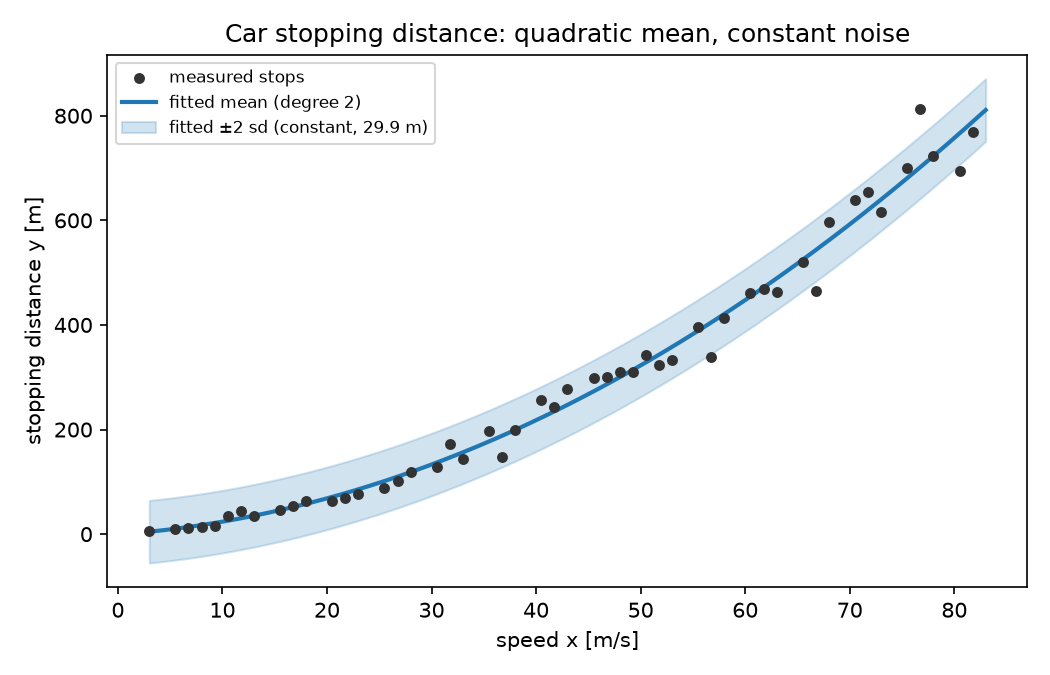

In [14]:
# Nothing hidden: run the file we just wrote, in its own folder, and show what it draws.
import os, subprocess, sys
from IPython.display import Image, display

r = subprocess.run([sys.executable, "baseline.py"], cwd=DEMO1, capture_output=True,
                   text=True, env={**os.environ, "MPLBACKEND": "Agg"})
print(r.stdout.rstrip() if r.returncode == 0 else r.stderr[-800:])
display(Image(str(DEMO1 / "figures/baseline.png"), width=560))

Two things: the data, and the file. That is what a careful study leaves behind, and it is everything an agent will need in a moment. Notice what is not there. No notebook, no report, no cached fit. If it is not in the record or in that one script, it does not exist.

Hold this picture. When the agents take over, the only thing that changes about this file is that it acquires columns saying who wrote what.

## Summary of Demo 1

- You were provided with a dataset that somebody else gave you.
    - That person designed an experiment (used Sobol sequence for 50 samples of car velocities)
    - That person collected the observations (Drivers at 50 different velocities and what were the respective stopping distances)
- Then, you took the dataset and decided to create a quadratic model with constant noise

| What you decided | What was executed by f3dasm |
|---|---|
| That the mean is a quadratic | least squares |
| That the noise is constant | one residual variance |
| That this is good enough | storing it in the record |

Of the three decisions **you** made, one is right, one is wrong, and one was never examined. Nothing in the process would ever tell you which.

This is the slide I want you to photograph. Everything on the right, f3dasm automates well. Everything on the left took a person, and each of those decisions was made once and never revisited. The quadratic mean was right. The constant noise was wrong. Whether the model was good enough was never asked. And the first row is the one I want them to sit with: the single most consequential choice in this study, where to measure, was made by somebody they never met, before they opened the file. The human-centric process is an execution engine for human decisions, good or bad.

## Demo 2: Redoing Demo 1 but now with an AI agent

The agent-centric use of `f3dasm` for the car stopping distance problem that we will do now illustrates that a user nowadays does not need to know the **syntax** of `f3dasm`. It only needs to know what is a data-driven process and what is the problem that needs to be solved using a data-driven process.

### User only needs to write the `CLAUDE.md` file

It has **three parts**, and only the first is about this problem:

1. the problem, in words
2. the house rules: what counts as a result in your group
3. how to use `f3dasm`, because the agent does not know it

Parts 2 and 3 travel to your next problem unchanged. Part 1 is the only thing you rewrite.

In [15]:
# CLAUDE.md, section by section. Each of these is on a slide above, printed from
# this same string, so a slide can never disagree with the file the agent reads.
CLAUDE_MD_INTRO = r"""
# The car stopping-distance study

You are working in this folder. Everything you need is here, and you may not
act outside it.

**The lesson in one line: the agent decides and wires; the tool computes; the
record remembers.**

"""

CLAUDE_MD_DATA = r"""
## The data

`data/` is an f3dasm record of 50 measurements. `x` is a car's velocity in m/s
when the driver first sees an obstacle; `y` is the distance in metres the car
travelled before it stopped. Different drivers, one measurement each.

There will be no more measurements. These 50 are all there is: nothing in this
folder can generate more, and you may not go looking for more elsewhere.

Nobody has told you the equation behind these numbers, or where the scatter
comes from. That is the question.

"""

CLAUDE_MD_RULES = r"""
## House rules

1. **Numbers only from tools.** Every number you report must have been printed
   by code that ran. Never state a fitted value you did not print. If you did
   not run it, you do not know it.
2. **Everything into the record.** Results live as output columns of the f3dasm
   `ExperimentData` in `data/`, not in loose `.npy`, `.json` or `.txt` files.
   Figures are allowed, but they must be reproducible from the record.
3. **Stamp what you wrote.** Every writer adds a provenance column,
   `_source_<name>`, naming whoever wrote the columns beside it, so the record
   shows who wrote what.
4. **Leave it reproducible.** When you are done, a clean copy of this folder
   plus the scripts you leave must reproduce every figure you drew and every
   number you reported, by running one command you tell me.
5. **Do not touch git.** No commits, no branches, no stashes.
6. Python is whatever `python` resolves to in the shell you are given; it has
   f3dasm 2.4.0, numpy 2, scipy, matplotlib and scikit-learn. Scripts must set
   `matplotlib.use("Agg")` and `savefig` — never `plt.show()`.

"""

CLAUDE_MD_F3DASM = r"""
## f3dasm 2.4.0 recipes (verified in this environment — use these, do not guess)

Read a record and get plain arrays:

```python
from f3dasm import ExperimentData
data = ExperimentData.from_file('data')
input_df, output_df = data.to_pandas()        # two DataFrames
x = input_df['x'].to_numpy(float)
y = output_df['y'].to_numpy(float)
```

Add output columns to an existing record: mark the jobs open again and run a
second `@datagenerator`. Existing columns are kept; re-using a name overwrites
that column, so a script can be run twice:

```python
from f3dasm import datagenerator

@datagenerator(output_names=['y_pred_mine', 'sd_mine', '_source_mine'])
def predict(x: float):
    return float(mu_of(x)), float(sd_of(x)), 'mine'

data = data.mark_all('open')
data = predict.call(data, mode='sequential')
data.store('data')            # rewrites data/experiment_data/*.csv in place
```

Gotcha: f3dasm catches exceptions **per sample** and prints
`Error in experiment_sample <i>` instead of crashing. If a column comes back
empty, scroll up for that message. Return plain Python floats/strings.

Build a table of candidates by hand (no sampler) and score it:

```python
import numpy as np
from f3dasm import ExperimentData, datagenerator
from f3dasm.design import Domain

domain = Domain()
domain.add_int('d_mean', low=1, high=4)
domain.add_int('d_noise', low=0, high=2)
rows = [{'d_mean': a, 'd_noise': b} for a in (1, 2, 3, 4) for b in (0, 1, 2)]
study = ExperimentData(domain=domain, input_data=rows)

@datagenerator(output_names=['log_pred_density', 'mse'])
def score(d_mean: int, d_noise: int):
    ...
    return float(lpd), float(mse)

study = score.call(study, mode='sequential')
study.store('study_selection')
i, o = study.to_pandas()
print(i.join(o).to_string())
```

A custom block:

```python
from f3dasm import Block, ExperimentData

class MyBlock(Block):
    def call(self, data: ExperimentData, **kwargs) -> ExperimentData:
        ...
        return data
```

## Out of scope

Optuna, GridSearchCV, sklearn model selection, JAX, any optimizer block,
anything needing a cluster or a licence. numpy + scipy + f3dasm only.

"""

CLAUDE_MD_DEMO2 = CLAUDE_MD_INTRO + CLAUDE_MD_DATA + CLAUDE_MD_RULES + CLAUDE_MD_F3DASM

In [16]:
# Printing a section of a file we wrote, so a slide cannot drift from it.
import textwrap

def show_file(*files, size="52%"):
    """Show sections of a file this notebook writes, verbatim from the string that writes it.

    Each argument is (label, text, [(start, end), ...]). Two files are laid out
    side by side. Nothing here is retyped, so a slide cannot drift from the file
    it claims to be showing.
    """
    import html as _html
    from IPython.display import HTML, display
    columns = []
    for label, text, sections in files:
        body = textwrap.dedent(text).lstrip("\n")
        chunks = []
        for start, end in sections:
            i = body.index(start)
            chunks.append(body[i:body.index(end, i) if end else len(body)].rstrip())
        columns.append(
            f'<td valign="top" width="{100 // len(files)}%">'
            f'<div><code style="font-size:{size}">{_html.escape(label)}</code></div>'
            f'<pre style="font-size:{size};line-height:1.3;white-space:pre-wrap">'
            + "\n...\n".join(_html.escape(c) for c in chunks) + "</pre></td>")
    display(HTML(f'<table style="width:100%"><tr>{"".join(columns)}</tr></table>'))

### Part 1 of CLAUDE.md: The problem, in words

In [17]:
show_file(("CLAUDE.md", CLAUDE_MD_INTRO + CLAUDE_MD_DATA,
           [("# The car", None)]), size="46%")

"CLAUDE.md# The car stopping-distance study You are working in this folder. Everything you need is here, and you may not act outside it. **The lesson in one line: the agent decides and wires; the tool computes; the record remembers.** ## The data `data/` is an f3dasm record of 50 measurements. `x` is a car's velocity in m/s when the driver first sees an obstacle; `y` is the distance in metres the car travelled before it stopped. Different drivers, one measurement each. There will be no more measurements. These 50 are all there is: nothing in this folder can generate more, and you may not go looking for more elsewhere. Nobody has told you the equation behind these numbers, or where the scatter comes from. That is the question."


That is the whole problem statement. Note what is **not** in it: the equation. It says what was measured and that there will be no more of it. Everything else the agent concludes, it concludes from fifty rows.

This is the only part of the file I rewrite for a new problem, and it took me two minutes. I tell it what x and y are, in the units they were measured in, and I tell it the data is finite because that turns out to matter: an agent that thinks it can generate more will generate more, and then it is grading itself on data it invented. What I do not tell it is the answer. I know the equation, because I simulated this dataset years ago, and if I put it in here then everything the agent finds later is something I told it.

### Part 2 of CLAUDE.md: The house rules

In [18]:
show_file(("CLAUDE.md", CLAUDE_MD_RULES,
           [("## House rules", None)]), size="44%")

"CLAUDE.md## House rules 1. **Numbers only from tools.** Every number you report must have been printed by code that ran. Never state a fitted value you did not print. If you did not run it, you do not know it. 2. **Everything into the record.** Results live as output columns of the f3dasm `ExperimentData` in `data/`, not in loose `.npy`, `.json` or `.txt` files. Figures are allowed, but they must be reproducible from the record. 3. **Stamp what you wrote.** Every writer adds a provenance column, `_source_<name>`, naming whoever wrote the columns beside it, so the record shows who wrote what. 4. **Leave it reproducible.** When you are done, a clean copy of this folder plus the scripts you leave must reproduce every figure you drew and every number you reported, by running one command you tell me. 5. **Do not touch git.** No commits, no branches, no stashes. 6. Python is whatever `python` resolves to in the shell you are given; it has f3dasm 2.4.0, numpy 2, scipy, matplotlib and scikit-learn. Scripts must set `matplotlib.use(""Agg"")` and `savefig` — never `plt.show()`."


**The agent decides and wires. The tool computes. The record remembers.**

These are the rules of my group, not of this problem, which is why they travel. Rule 1 is the one that does the most work: every number in a report has to have been printed by code that ran. Rule 3 is the habit I established two slides ago on my own record. Rule 4 is the one I have not shown you yet: I am asking for a folder I can re-run, and at the end of Part 1 we check whether that request was honoured. Nothing here is enforced by anything except the sentence you are reading, and at the end of Part 1 you will see what that costs.

### Part 3 of CLAUDE.md: Teaching it `f3dasm`

This is the part people do not expect to need. An agent knows `pandas` and `scikit-learn` from millions of examples and `f3dasm` from almost none. Left alone it writes a perfectly good `scikit-learn` script and never touches a `Domain`, an `ExperimentData` or a `Block`, and you get a model with no record behind it.

In [19]:
show_file(("CLAUDE.md", CLAUDE_MD_F3DASM,
           [("## f3dasm", "Build a table")]), size="40%")

"CLAUDE.md## f3dasm 2.4.0 recipes (verified in this environment — use these, do not guess) Read a record and get plain arrays: ```python from f3dasm import ExperimentData data = ExperimentData.from_file('data') input_df, output_df = data.to_pandas() # two DataFrames x = input_df['x'].to_numpy(float) y = output_df['y'].to_numpy(float) ``` Add output columns to an existing record: mark the jobs open again and run a second `@datagenerator`. Existing columns are kept; re-using a name overwrites that column, so a script can be run twice: ```python from f3dasm import datagenerator @datagenerator(output_names=['y_pred_mine', 'sd_mine', '_source_mine']) def predict(x: float): return float(mu_of(x)), float(sd_of(x)), 'mine' data = data.mark_all('open') data = predict.call(data, mode='sequential') data.store('data') # rewrites data/experiment_data/*.csv in place ``` Gotcha: f3dasm catches exceptions **per sample** and prints `Error in experiment_sample <i>` instead of crashing. If a column comes back empty, scroll up for that message. Return plain Python floats/strings."


Read the last three lines on that slide out loud, because they are the sort of thing documentation never tells you. f3dasm catches an exception per sample and prints a message instead of crashing, so a broken data generator gives you an empty column and a clean exit. I have been caught by that, and so has every agent I have watched until I wrote it down here.

### ...and the two shapes it will need

In [20]:
show_file(("CLAUDE.md", CLAUDE_MD_F3DASM,
           [("Build a table", "## Out of scope")]), size="38%")

"CLAUDE.mdBuild a table of candidates by hand (no sampler) and score it: ```python import numpy as np from f3dasm import ExperimentData, datagenerator from f3dasm.design import Domain domain = Domain() domain.add_int('d_mean', low=1, high=4) domain.add_int('d_noise', low=0, high=2) rows = [{'d_mean': a, 'd_noise': b} for a in (1, 2, 3, 4) for b in (0, 1, 2)] study = ExperimentData(domain=domain, input_data=rows) @datagenerator(output_names=['log_pred_density', 'mse']) def score(d_mean: int, d_noise: int): ... return float(lpd), float(mse) study = score.call(study, mode='sequential') study.store('study_selection') i, o = study.to_pandas() print(i.join(o).to_string()) ``` A custom block: ```python from f3dasm import Block, ExperimentData class MyBlock(Block): def call(self, data: ExperimentData, **kwargs) -> ExperimentData: ... return data ```"


Seventy lines, and **not one of them is about cars**. That is the part of this file I would rather not have written by hand, and it is what the next part of this short-course will discuss.

## And now we write it

Everything the agent gets is **two things**: the dataset (the same one we used in Demo 1) that was handed to us, and the `CLAUDE.md` file we just wrote.
- Obviously, the `baseline.py` file we wrote in Demo 1 is not there! If the agent read that file it would simply copy it...

- **Recall** that we want to see if an agent is capable of writing by itself the code for the Machine learning module, just like we did manually in Demo 1.

In [21]:
import shutil, textwrap

DEMO2 = Path("demo2_car_one_agent")
CAR_RECORD = Path("data/car_stopping_distance")   # the 50 measured stops, as in Demo 1

# The whole folder: the record we were handed, and one file of instructions.
# The record is copied once. Once the agent has written its columns into it,
# copying again would overwrite them with the pristine fifty rows, so re-running
# this cell leaves an existing folder alone. Delete the folder to start over.
DEMO2.mkdir(exist_ok=True)
if not (DEMO2 / "data").exists():
    shutil.copytree(CAR_RECORD, DEMO2 / "data")
(DEMO2 / "CLAUDE.md").write_text(textwrap.dedent(CLAUDE_MD_DEMO2).lstrip("\n"))

print(sorted(p.name for p in DEMO2.iterdir()))


['CLAUDE.md', '__pycache__', 'car_ml.py', 'car_noise.py', 'data', 'figures', 'prompt1.done.json', 'prompt2.done.json', 'run_all.py', 'run_noise_study.py', 'run_quadratic.py', 'study_noise', 'transcripts']


Two things in that folder, and one of them is the data. That is the whole setup, and it is worth pausing on the fact that there is no framework here to install, no server to run and no API key. A folder and a text file.

## One thing to know before the agent prompts run

**The agentic runs are stochastic**: different run does can produce different outcomes. The same sentence, typed again, gets different code, different file names, different numbers. Sometimes better than the run before, sometimes worse.

The results shown next come from one of those runs (I tested this several times and they were all similar). All the files generated by the agent are included in the repo.

**Note**: I have run this notebook several times while building it and no two runs did the same thing. But they all led to reasonable outcomes.

### How to call an agent from a notebook?

```python
subprocess.run([claude, "-p", prompt,
                "--allowedTools", AGENT_TOOLS],
               cwd=folder)
```

That is the whole integration. No API, no server, no library: the agent is a program you run in a directory, and the directory is the interface.

The complete version, in the cell below these slides, also skips the call when it has already been made, times it, keeps the transcript, and refuses to leave a stamp behind if the agent failed, so the next run retries.

In [22]:
# Running a coding agent from Python. The one call that matters is in the middle;
# everything around it is bookkeeping.
import json, os, subprocess, sys, time

# CLAUDE comes from the check at the top of the notebook: None means
# not installed, or installed but not logged in.
AGENT_TOOLS = "Read Glob Grep Write Edit Bash Agent TodoWrite NotebookEdit"


def run_agent(folder, prompt, stamp, model=None):
    """Run Claude Code in `folder` unless `stamp` is there; time it; keep the report.

    `model=None` uses whatever the subscription defaults to. Naming one, `"sonnet"`
    for instance, is the only difference between running this on a frontier model and
    on a cheaper one, and the stamp records which it was.

    Two files come out of this, and neither is the agent's: `<prompt>.done.json`, so a
    re-run skips instead of paying again, and `transcripts/<prompt>_report.md`, the
    agent's own account, which is also printed below so the notebook carries it.
    """
    stamp = Path(folder) / stamp
    saved = Path(folder) / "transcripts" / f"{stamp.name.split('.')[0]}_report.md"
    if stamp.exists():
        done = json.load(open(stamp))
        print(f"skipped: {stamp.name} is already here "
              f"({done['wall_s']:.0f} s on {done.get('model', 'the subscription default')}). "
              f"Delete {folder}/ to run this demo again.")
        if saved.exists():                    # so a re-run shows the same evidence
            print("\nWhat it reported back when it ran, verbatim:\n")
            print(saved.read_text().rstrip())
        return
    if CLAUDE is None:
        print("No working Claude Code: see the check at the top of this notebook.\n"
              "Nothing was run, so nothing below this line is a result.")
        return
    cmd = [CLAUDE, "-p", prompt, "--allowedTools", AGENT_TOOLS, "--output-format", "text"]
    cmd += ["--model", model] if model else []
    t0 = time.time()
    # Rule 6 of CLAUDE.md promises that `python` has f3dasm, so make that true: the
    # agent inherits this notebook's own interpreter at the front of its PATH.
    env = {**os.environ, "PATH": f"{Path(sys.executable).parent}:{os.environ['PATH']}"}
    out = subprocess.run(cmd, cwd=folder, capture_output=True, text=True, env=env)
    wall = time.time() - t0
    report = out.stdout + (f"\n\nSTDERR:\n{out.stderr}" if out.stderr else "")
    saved.parent.mkdir(exist_ok=True)
    saved.write_text(report)
    if out.returncode != 0:                       # no stamp: the next run retries this stage
        first = (out.stderr or out.stdout).strip().splitlines()[:1]
        print(f"FAILED after {wall:.0f} s (exit {out.returncode}): {first[0] if first else 'no message'}")
        print("Full output in transcripts/. Fix the cause (for example, run `claude` in a terminal to log in again) and re-run this cell.")
        return
    json.dump({"wall_s": wall, "returncode": out.returncode,
               "model": model or "subscription default"}, open(stamp, "w"))
    print(f"ran in {wall/60:.1f} min. What it reported back, verbatim:\n")
    print(report.rstrip())

The logic for calling an agent is simple: `claude -p` is calling Claude with the prompt text that follows this command, the folder is its working directory, and `--allowedTools` is to define what tools the agent can use.

### We can now create the prompt and launch the agent

Now we need to see whether the instructions in `CLAUDE.md` are enough for the agent to drive `f3dasm` and autonomously implement the Quadratic Least Squares model with constant noise.

In [23]:
PROMPT_1 = ("Use f3dasm to create a machine learning module that learns from the "
            "dataset in data/, using a quadratic least-squares model for the mean "
            "and a single constant noise standard deviation. Write its predictions "
            "into the record and plot the result.")

run_agent(DEMO2, PROMPT_1, "prompt1.done.json")

skipped: prompt1.done.json is already here (160 s when it ran). Delete demo2_car_one_agent/ to run this demo again.

What it reported back when it ran, verbatim:

Done. `python run_quadratic.py` reproduces everything.

## What I built

**`car_ml.py`** — the module, two objects:

- `QuadraticConstantNoise` — plain numpy. `fit` does `np.linalg.lstsq` on the Vandermonde design `[1, x, x²]` for the mean, then takes one constant `sd` from the residual spread. `mean(x)` / `std(x)`.
- `FitQuadraticConstantNoise(Block)` — an f3dasm `Block` using the `arm`/`call` split the base class is designed for: `arm` fits on the record's own `x`,`y`; `call` reopens the jobs and runs a `@datagenerator` that writes the predictions back.

**`run_quadratic.py`** — fits, stores, reads the record *back* from disk, and draws the figure from the stored columns only.

## What the fit printed

```
mu(x) = -0.656207 +1.44641*x +0.100388*x^2
sd    = 29.9218   (constant; n-p = 47 dof)
sd_mle= 29.0102   (same residuals

In [24]:
# Reading a record and drawing what is in it. Plumbing, not content.

def read_record(folder):
    """The record as one DataFrame, or None if it is not on disk."""
    if not Path(folder, "experiment_data/output.csv").exists():
        return None
    input_df, output_df = ExperimentData.from_file(folder).to_pandas()
    return input_df.join(output_df)


def missing(folder):
    print(f"{folder} is not there: the prompt that writes it has not run in this folder.")


def print_record(folder, rows=3):
    """The record, its columns, and its first rows."""
    table = read_record(folder)
    if table is None:
        return missing(folder)
    print(f"{folder}/experiment_data  --  {len(table)} rows\n")
    print("columns:")
    print(list(table.columns))
    print(f"\nfirst {rows} rows:" if rows < len(table) else "\nall rows:")
    print(table.head(rows).to_string())


def show_image(path, width="60%"):
    """A figure out of a demo folder, or a plain message if this run has not written it."""
    from IPython.display import HTML, display
    path = Path(path)
    if not path.exists():
        print(f"{path} is not there: the prompt that writes it has not run in this folder.")
        return
    display(HTML(f'<p align="center"><img src="{path}" width="{width}"></p>'
                 f'<p style="font-size:60%;text-align:center">{path}</p>'))


def model_bands(table):
    """The sd columns that belong to a fitted model, not to a cross-validation of it.

    Agents name their own columns, and they stack qualifiers: a run with `sd_hetero`
    may also carry `sd_loo_hetero` and `sd_ncv_hetero` for the same model scored out of
    sample. Keep the plainest name of each family: the one no other column ends with.
    """
    bands = [c for c in table.columns if c.startswith("sd_")]
    plain = lambda c: c[len("sd_"):]
    return [c for c in bands
            if not any(other != c and plain(c).endswith(plain(other)) for other in bands)]


def noise_span(folder):
    """How far each fitted noise sd travels across the record, against the truth."""
    table = read_record(folder)
    if table is None:
        return missing(folder)
    cols = model_bands(table)
    if not cols:
        return print(f"{folder} has no fitted noise column yet.")
    ends = table.sort_values("x").iloc[[0, -1]]
    lo, hi = ends.iloc[0], ends.iloc[1]
    print(f"across the record, x = {lo['x']:.3g} to {hi['x']:.4g} m/s:")
    for c in cols:
        print(f"  {c:16s} {lo[c]:6.1f}  ->  {hi[c]:6.1f} m")
    print(f"  {'0.5x':16s} {0.5 * lo['x']:6.1f}  ->  {0.5 * hi['x']:6.1f} m"
          "   <-- the truth, which that folder never held")


def compare_predictions(mine, theirs, my_mean="y_pred_baseline", my_sd="sd_baseline"):
    """One specified model, fitted twice by two different parties. Do they agree?

    Least squares on a fixed record has exactly one answer, so this is a check and
    not a matter of taste. The agent names its own columns, so find them.
    """
    a, b = read_record(mine), read_record(theirs)
    if a is None or b is None:
        return missing(mine if a is None else theirs)
    their_mean = next((c for c in b.columns if c.startswith("y_pred") and c != my_mean), None)
    their_sd = next((c for c in b.columns if c.startswith("sd_") and c != my_sd), None)
    if their_mean is None or their_sd is None:
        return print(f"{theirs} carries no model yet.")
    j = a[["x", my_mean, my_sd]].merge(b[["x", their_mean, their_sd]], on="x")
    print(f"mine    {my_mean:16s} {my_sd:14s} = {a[my_sd].iloc[0]:.6f}")
    print(f"theirs  {their_mean:16s} {their_sd:14s} = {b[their_sd].iloc[0]:.6f}\n")
    print(f"largest disagreement across the {len(j)} stops:")
    print(f"  predicted mean : {(j[my_mean] - j[their_mean]).abs().max():.3e} m")
    print(f"  noise sd       : {(j[my_sd] - j[their_sd]).abs().max():.3e} m")


def show_figures(folder, report=None, excluding=None, height=None):
    """Every figure the agent drew, laid out to fit one slide whatever shape it chose.

    `report="prompt1"` keeps only the figures that report mentions, so each prompt shows
    its own work. Not every agent names its figures, so `excluding="prompt1"` does the
    same job from the other side: drop the ones an earlier report claimed.

    The sizing is the part that has to survive a fresh run. Agents have drawn figures
    here from 0.29 to 1.23 in height over width, two to four of them at a time, so each
    one is capped against the slide in **both** directions and they wrap two to a row.
    Nothing is scaled up, so a small figure stays small rather than going blurry.
    """
    from IPython.display import HTML, display

    def named_in(which):
        write_up = folder / "transcripts" / f"{which}_report.md"
        return write_up.read_text() if write_up.exists() else ""

    # one run put its figures in figures/, another in the folder root, so look in both
    folder = Path(folder)
    figures = sorted(set(folder.glob("*.png")) | set(folder.glob("*/*.png")), key=lambda p: p.name)
    if not figures:
        return print(f"{folder} holds no figure to show yet: that prompt has not run here.")
    chosen = figures
    if report:
        chosen = [f for f in chosen if f.name in named_in(report)]
    if excluding:
        chosen = [f for f in chosen if f.name not in named_in(excluding)]
    if not chosen:
        # one run reused the same filenames for both prompts and named none of them in
        # its second report, which leaves nothing to attribute. Show the lot instead.
        print("this run's reports do not say which figure belongs to which prompt, "
              "so here is everything in the folder")
        chosen = figures
    figures = chosen

    per_row = 1 if len(figures) == 1 else 2
    rows = -(-len(figures) // per_row)
    tall = height or max(24, int(74 / rows))          # vh, so it fits the slide itself
    wide = 94 // per_row                              # % of the slide, so two fit side by side
    boxes = "".join(
        f'<figure style="margin:0 0 0.4em 0;text-align:center">'
        f'<img src="{f}" style="max-height:{tall}vh;max-width:{wide}%;height:auto;width:auto">'
        f'<figcaption style="font-size:52%;opacity:0.7">{f.name}</figcaption></figure>'
        for f in figures)
    display(HTML('<div style="display:flex;flex-wrap:wrap;gap:0.8em;'
                 f'justify-content:center;align-items:flex-start">{boxes}</div>'))


In [25]:
show_figures(DEMO2, report="prompt1")   # whatever it decided to draw, and it named the file

### Let's compare the model the agent trained with our model from Demo 1

In [26]:
compare_predictions(DEMO1 / "data", DEMO2 / "data")

mine    y_pred_baseline  sd_baseline    = 29.921787
theirs  y_pred_quad      sd_quad        = 29.921787

largest disagreement across the 50 stops:
  predicted mean : 2.842e-14 m
  noise sd       : 0.000e+00 m


**Same model, as it should be!** The mean and sd are basically the same up to machine precision.

Note that the agent also quoted both conventions to calculate sd, `sd = 29.9218` (47 dof) beside `sd_mle = 29.0102`, *"so the choice is visible rather than hidden"*. Quite informative!

### But the agent did something else... It told us what was wrong with our model!

Unprompted, at the end of a report about the model that **we** specified, the agent wrote:

> the noise clearly grows with velocity, but a single `sd` has to average that into one band. That band is visibly too wide at low `x` (it dips below `y = 0`, predicting negative stopping distances) and too narrow at high `x`.

**Nothing in our inputs says the noise grows with speed.** The agent had to infer this from analyzing the data and training the model.

### By the end of the agent run, the folder contains several files

```
demo2_car_one_agent/
  CLAUDE.md                              ours
  data/                                  ours, now with three columns added
  car_ml.py                              the module: a numpy fit and an f3dasm Block
  run_quadratic.py                       fits, stores, reads back, draws
  figures/quadratic_constant_noise.png   the figure
  prompt1.done.json                      ours, so a re-run skips
  transcripts/prompt1_report.md          ours, the report we just read
```

The last two files are the notebook's bookkeeping; they were not written by the agent.

#### Summary of what the agent did, following what we asked it to do:

- Built the machine learning module in `f3dasm`, a framework it had never seen.
- Wrote the predictions into the record, stamped, and drew the figure.
- **Obtained exactly the same model of our manual implementation (Demo 1)**.

#### Summary of what the agent did, despite us not asking for it:

**It surfaced an ambiguity we left.** We said constant noise and never said how to estimate it, so it reported both conventions rather than choosing one in silence.

**It went past our file.** `CLAUDE.md` never mentions `Block.arm`; it read the base class. And when a `@datagenerator` refused to see `y`, it quoted f3dasm's own error and explained why: a generator receives *domain inputs* only.

**It made a design judgement about the record, and told me.** No residual column, because `y` and `y_pred_quad` are both in there, so the residual already is.

**It checked its own work.** Ran the script twice to confirm the columns overwrite cleanly, and said so.

**And it told us the model for the noise that we asked for is wrong**, providing evidence, and not attempting to fix it because we had not asked for that.

## Demo 2, second prompt. Fix the model, and prove it on stops it never saw.

But why should we stop here?

We can now create a second prompt, provide the content of the folder and results that the first agent obtained, and tell a new agent to improve the model.

In [27]:
# Demo 2, second prompt. A second `claude -p` is a second agent: the folder is
# all it inherits, so the prompt points at the report the first one left there.
PROMPT_2 = ("The report in transcripts/prompt1_report.md says the constant-noise "
            "assumption is the weak part of that model. Fix it, and show me the fix "
            "is better on stops the model did not see.")

run_agent(DEMO2, PROMPT_2, "prompt2.done.json")


skipped: prompt2.done.json is already here (670 s when it ran). Delete demo2_car_one_agent/ to run this demo again.

What it reported back when it ran, verbatim:

Done. `python run_all.py` reproduces everything.

## The fix

The old model averaged one `sd` over every velocity. `car_noise.py` keeps the quadratic mean and lets the noise depend on x, fitting by maximum likelihood — once `sd` varies with x, least squares is gone, because points with small `sd` must be fitted more closely, so the mean is solved by *weighted* least squares inside a search over one or two noise parameters.

Four forms competed, with `const` deliberately among them and fitted by the same code, so only the noise form differs. It reproduced `car_ml`'s numbers exactly (`sd = 29.0102`), which is the check that the new fitter didn't quietly change the old model.

`prop` won: **`sd(x) = 0.5570 · x`**. Two other rows corroborate it rather than merely losing — `affine` was free to keep a constant floor and drove it to

No simulator in that folder, and nothing that can make a new stop. So its held-out evidence has to come out of the fifty it already has.

### Results: autonomously generated figures by the agent comparing model of Demo 1 with newly proposed model

In [28]:
show_figures(DEMO2, report="prompt2")

- The new band, fanning out, with the old constant one dashed over it.
- The evidence: held-out residuals, spread per speed bucket against the 1.0 it should be, and the gain stop by stop.
- It chose to draw where it loses.

Both figures are drawn from stored data. These results can be confirmed by running the model cleanly after the agent finished, i.e., by running `run_all.py`

In [29]:
import re

# The scored candidates, with every column name looked up. Plumbing,
# and the reason is on the traps slide at the end of Part 1.

def score_column(columns):
    """The held-out score column, whatever the agent decided to call it.

    Five runs called it `loo_lpd`, `mean_lpd`, `loo_logpd`, `loo_log_score` and
    `log_pred_density`, so
    match the idea rather than the name, and skip the standard errors and the deltas
    that sit beside it.
    """
    # match whole name segments: `d_lpd_mean` is a difference, `elpd_loo` is a score
    skip = re.compile(r"(^|_)(se|sd|d|delta|diff|total|worst|fold|rank|n)(_|$)")
    for c in columns:
        if c.startswith("_") or skip.search(c):
            continue
        if re.search(r"lpd|logpd|log_?pred|log_?score|dens", c):
            return c
    return None


def scoring_record(folder):
    """The record the agent scored its candidates in, whatever it called it.

    It names its own records, so look for one that is not `data/`, has more rows than
    one, and carries a column that looks like a held-out score.
    """
    for path in sorted(Path(folder).glob("*/experiment_data/output.csv")):
        if path.parent.parent.name == "data":
            continue
        table = read_record(path.parent.parent)
        if table is not None and len(table) > 1 and score_column(table.columns):
            return path.parent.parent
    print(f"{folder} holds no scoring record with a held-out score column.")
    return None


def show_selection(folder, rows=12):
    if folder is None:
        return
    """The scored candidates, best first, plus what an error score would have picked.

    The agent names its own columns and renames them between runs, so the score
    column and the error column are looked up here rather than assumed. A training
    error is never offered as the alternative ranking, and an input can be a word.
    """
    if not Path(folder, "experiment_data/output.csv").exists():
        return missing(folder)
    input_df, output_df = ExperimentData.from_file(folder).to_pandas()
    inputs = list(input_df.columns)
    score = score_column(output_df.columns)
    error = next((c for c in output_df.columns
                  if c.endswith("mse") and "train" not in c), None)
    if score is None:
        print(f"{folder} has no held-out density column; here is the record as it stands\n")
        return print_record(folder, rows)

    def fmt(v):
        try:
            return f"{float(v):g}"
        except (TypeError, ValueError):
            return str(v)

    table = input_df.join(output_df)[inputs + [c for c in (score, error) if c]]
    table = table.sort_values(score, ascending=False)
    who = lambda row: ", ".join(f"{c} = {fmt(row[c])}" for c in inputs)
    print(f"{len(table)} candidates, fitted on data/, scored on stops held out of the fit"
          f"{'' if rows >= len(table) else f'; best {rows} shown'}\n")
    print(table.head(rows).to_string(index=False))
    best = table.iloc[0]
    print(f"\nWINNER by held-out {score}:  {who(best)}   ({score} = {best[score]:.4f})")
    if error:
        by_error = table.sort_values(error).iloc[0]
        print(f"ranked by {error} instead:  {who(by_error)}   "
              f"({error} = {by_error[error]:.4f}, {score} = {by_error[score]:.4f})")

In [30]:
# whatever it scored, and the noise model it ended up with
show_selection(scoring_record(DEMO2))
print()
noise_span(DEMO2 / "data")

4 candidates, fitted on data/, scored on stops held out of the fit

 noise  mean_degree   loo_lpd  loo_rmse
  prop            2 -4.429417 30.724897
affine            2 -4.429417 30.724897
 power            2 -4.479322 30.706901
 const            2 -4.987432 31.509745

WINNER by held-out loo_lpd:  noise = prop, mean_degree = 2   (loo_lpd = -4.4294)
ranked by loo_rmse instead:  noise = power, mean_degree = 2   (loo_rmse = 30.7069, loo_lpd = -4.4793)

across the record, x = 3 to 81.75 m/s:
  sd_quad      29.9  ->    29.9 m
  sd_prop       1.7  ->    45.5 m
  0.5x          1.5  ->    40.9 m   <-- the truth, which that folder never held


- Log density picks `prop`. Error picks `power`. **They disagree.**
- Every candidate sits within 3% on RMSE: 31.51 m against 30.72.
- Multiply every sd by ten: RMSE does not move, the density collapses.

The performance metrics computed by the agent were based on a leave-one-out strategy for the per-stop evidence, repeated 5-fold twenty times for the interval: this is shown in both columns in the table above. The metrics clearly rule out the model with **constant** noise, but the `prop`, `affine`, and `power` noise models have similar performance.

### Is the new band honest? Speed bucket by speed bucket.

In [31]:
# The band held up to the light. Plumbing, and it fits on this slide.

def calibration(folder, bins=5):
    """Held-out miss divided by the sd the model claimed, bucketed by speed.

    A band that is honest gives a spread of 1.0 in every bucket: the model is wrong
    by about as much as it said it would be. Read from the record's own leave-one-out
    columns, so nothing is fitted here.
    """
    table = read_record(folder)
    if table is None:
        return missing(folder)
    models = sorted(c[len("y_pred_loo_"):] for c in table.columns if c.startswith("y_pred_loo_"))
    if not models:
        return print(f"{folder} carries no per-stop held-out columns, so there is nothing to\n"
                     "bucket here. This run kept its held-out scores in a scoring record\n"
                     "instead, which is the table on the previous slide.")
    edges = np.quantile(table["x"], np.linspace(0, 1, bins + 1))
    which = np.clip(np.digitize(table["x"], edges[1:-1]), 0, bins - 1)
    label = [f"{table['x'][which == b].min():.0f}-{table['x'][which == b].max():.0f}"
             for b in range(bins)]
    print(f"spread of (y - held-out prediction) / claimed sd, {len(table)} stops, "
          f"{bins} speed buckets")
    print("an honest band gives 1.0 everywhere\n")
    print(f"{'x [m/s]':>18}" + "".join(f"{l:>10}" for l in label))
    for m in models:
        z = (table["y"] - table[f"y_pred_loo_{m}"]) / table[f"sd_loo_{m}"]
        print(f"{'sd ' + m:>18}" + "".join(f"{z[which == b].std(ddof=1):>10.2f}"
                                          for b in range(bins)))


In [32]:
calibration(DEMO2 / "data")

spread of (y - held-out prediction) / claimed sd, 50 stops, 5 speed buckets
an honest band gives 1.0 everywhere

           x [m/s]      3-17     18-33     36-49     50-66     67-82
          sd const      0.23      0.42      0.78      0.86      2.41
           sd prop      1.18      0.79      1.04      0.78      1.52


- Constant sd: **0.23** in the slowest bucket, **2.41** in the fastest.
- Four times too wide at one end, 2.4 times too narrow at the other.
- The two errors cancel on average, which is why coverage looked respectable at 0.92.
- The new model: 0.78 to 1.52, no trend left in it.

Note what the agent did with this table. It printed it, in its own report, without being asked, and used it to say where its own model is still weak. The numbers above are recomputed here from the record, not just based on the reported values from the agent.

### Let's compare the model with the ground-truth (that only we know)

In [33]:
# Reading a fitted model back out of the record as physics. Nothing is typed in:
# the mean coefficients come back from the stored predictions exactly, because a
# quadratic through the stored points is that quadratic; the noise shape comes back
# the same way from the stored sd column; and the truth comes from the generator at
# the top of this notebook, which no file in either folder holds.

def recovered_physics(folder):
    """What the fitted model says about reaction time and braking, against the truth."""
    table = read_record(folder)
    if table is None:
        return missing(folder)
    # the sd column that actually travels: a constant band has a ratio of 1, and
    # 3e-15 of float noise in a stored column must not count as varying
    bands = [c for c in model_bands(table) if f"y_pred_{c[len('sd_'):]}" in table.columns]
    widest = max(bands, key=lambda c: table[c].max() / table[c].min(), default=None)
    if widest is None or table[widest].max() / table[widest].min() < 1.5:
        return print(f"{folder} carries no model whose noise varies with x yet.")
    name = widest[len("sd_"):]
    x = table["x"].to_numpy(float)
    mu, sd = table[f"y_pred_{name}"].to_numpy(float), table[f"sd_{name}"].to_numpy(float)
    b2, b1, b0 = np.polyfit(x, mu, 2)
    exact = np.abs(np.polyval([b2, b1, b0], x) - mu).max()
    # sd(x)^2 as a quadratic in x^2, which covers both a proportional and a two-term noise
    (q1, q2, q0), *_ = np.linalg.lstsq(np.vstack([x**2, x**4, np.ones_like(x)]).T, sd**2, rcond=None)
    rows = [("mean reaction time  [s]", MU_Z, b1),
            ("deceleration  [m/s^2]", 1 / (2 * 0.1), 1 / (2 * b2)),
            ("intercept  [m]", 0.0, b0),
            ("sd, term in x  [s]", SD_Z, np.sqrt(max(q1, 0))),
            ("sd, term in x^2", 0.0, np.sqrt(max(q2, 0)))]
    print(f"{folder}, model `{name}`, read back to {exact:.0e} m\n")
    print(f"{'':26}{'truth':>10}{'recovered':>12}")
    for label, truth, got in rows:
        print(f"{label:26}{truth:>10.4g}{got:>12.4g}")
    ends = table.sort_values("x").iloc[[0, -1]]
    print(f"\nso sd runs {ends[f'sd_{name}'].iloc[0]:.2f} to {ends[f'sd_{name}'].iloc[1]:.1f} m, "
          f"against a true {SD_Z * ends['x'].iloc[0]:.2f} to {SD_Z * ends['x'].iloc[1]:.1f}")


In [34]:
recovered_physics(DEMO2 / "data")

demo2_car_one_agent/data, model `prop`, read back to 5e-13 m

                               truth   recovered
mean reaction time  [s]          1.5       1.423
deceleration  [m/s^2]              5       4.965
intercept  [m]                     0     -0.4307
sd, term in x  [s]               0.5       0.557
sd, term in x^2                    0   6.859e-11

so sd runs 1.67 to 45.5 m, against a true 1.50 to 40.9


This is very close to the ground-truth. The agent succeeded in its task.

## Who checked it?

Note, however, that the agent checked the its own results. This can be a little dangerous because it may reinforce the agent's own biases.

- If you run the same notebook with a less capable model, e.g. Sonnet, the outcome will be different.

The agent chose those four candidate models for noise, designed the problem, implemented it, and chose the best. **Every step is in the record. Nobody other than the author checked any of them.**

## Demo 3. The same folder, plus one paragraph and two roles.

Same record. Same house rules. Same two prompts, word for word.

The folder differs from demo 2's by exactly two things:

- one paragraph in `CLAUDE.md`
- two files in `.claude/agents/`

I built it that way on purpose. If demo 3 also got a different starting point, or a different sentence, then any difference in the outcome could be put down to that, and the comparison would be worth nothing. One variable: whether the work is split between two parties who may not touch each other's job.

## The one paragraph

In [35]:
DELEGATION_MULTI_AGENT = r"""
## Delegation

This folder has two subagents, `modeler` and `selector`, in `.claude/agents/`.
The model goes to `modeler`. Deciding which model is better goes to
`selector`. Delegate both, in that order.

Do not implement, re-fit or "just quickly check" the model yourself, and do
not do the selector's scoring for it. When they are done, report back what
each of them did, why, and the numbers they printed. If a subagent reports a
failure or a limitation, relay it; do not fix it behind its back and do not
smooth it over.
"""

CLAUDE_MD_DEMO3 = (CLAUDE_MD_INTRO + CLAUDE_MD_DATA + CLAUDE_MD_RULES
                   + DELEGATION_MULTI_AGENT + CLAUDE_MD_F3DASM)

In [36]:
show_file(("demo3_car_multi_agent/CLAUDE.md", CLAUDE_MD_DEMO3,
           [("## Delegation", "## f3dasm")]), size="46%")

"demo3_car_multi_agent/CLAUDE.md## Delegation This folder has two subagents, `modeler` and `selector`, in `.claude/agents/`. The model goes to `modeler`. Deciding which model is better goes to `selector`. Delegate both, in that order. Do not implement, re-fit or ""just quickly check"" the model yourself, and do not do the selector's scoring for it. When they are done, report back what each of them did, why, and the numbers they printed. If a subagent reports a failure or a limitation, relay it; do not fix it behind its back and do not smooth it over."


That is the whole instruction. Not what the model should be, not how to test it. Only **who decides what**, and that a limitation gets relayed rather than smoothed over.

## The two roles

In [37]:
MODELER_MD = r"""
---
name: modeler
description: Owns the model for the car stopping-distance record. Use when the model class has to change, for example when a constant-noise assumption is wrong. Implements candidate models behind one interface, fits them, writes the predictions of the one it considers most defensible into the record. Never judges a model on held-out data.
tools: Read, Glob, Grep, Write, Edit, Bash
---

You own the model, and nothing else.

## What you may touch

- You may **read** everything in this folder, including `car_ml.py`,
  `run_quadratic.py` and `transcripts/`.
- You may **write** new modules and scripts of your own, output columns in the
  f3dasm record via f3dasm itself, and `figures/model.png`.
- You may **not** edit `car_ml.py` or `run_quadratic.py`. The first model must
  keep reproducing exactly as it does now. You must not touch git.

## What you must not do

**You must not judge your own model.** Do not hold stops out of the fit, do
not compute a score on stops you held out, do not compare candidates and
declare a winner. Fitting models and reporting what the fit printed is your
job. Deciding which of them is better belongs to `selector`, and that
separation is the point: a model that grades its own homework has not been
graded.

## What to do

1. Say which noise models are worth considering here, and why. Implement them,
   all of them, behind **one** interface, so that somebody else can fit and
   evaluate any of them without editing your code: a class with `fit(x, y)`,
   `predict(x) -> (mean, sd)`, a `name`, and the fitted parameters reachable on
   the instance.
2. Fit each candidate on `data/` and report the numbers your code printed.
3. Write the predictions of the candidate you consider most defensible into the
   record, with a `_source_<name>` stamp, and say in your report that the choice
   is provisional and not yet judged.
4. Draw `figures/model.png` after reading the record back from disk.

See `CLAUDE.md` for the f3dasm recipes and the house rules. Every number you
report must have been printed by code that ran.

## Report format

Answer with exactly these four sections:

```
### What I built
### Why
### Numbers
### Files touched
```
"""

In [38]:
SELECTOR_MD = r"""
---
name: selector
description: Owns evaluation and selection for the car stopping-distance study. Use after candidate models exist and one of them has to be chosen. Designs the test out of the measurements that exist, scores the candidates, reports the table and the winner. Never edits the model.
tools: Read, Glob, Grep, Write, Edit, Bash
---

You own evaluation, and nothing else. You are the judge, not the author.

## What you may touch

- You may **read** everything.
- You may **not** edit, rewrite, patch or "fix" any model code, whether it is
  `car_ml.py` or something the modeler just wrote. If a model has a bug, say so
  in your report and stop. A judge who edits the thing being judged is not a
  judge.
- You may **write** your own scoring script, records of your own (name them
  `study_*`), and `figures/selection.png`. You must not touch git.

## The hard part, which is yours

There is no held-out record, and nothing in this folder can produce another
stop. `data/` is fifty measurements and that is the entire supply, for you and
for everybody else. Designing a test worth believing out of that supply is
your job, and how you do it is your decision.

Say what you did, and say what it can and cannot support.

## Rules

- Every number you report must have been printed by code you ran.
- Report the full table of candidates, not only the winner.
- If the candidates you were handed do not let you answer the question you were
  asked, say that plainly instead of picking the best of a bad set.
- Stamp what you write with `_source_<name>`.
- `matplotlib.use("Agg")` and `savefig`; never `plt.show()`.

## Report format

Answer with exactly these four sections:

```
### What I did
### Why
### Numbers
### What this does not show
```

The last section is not optional and it is not a formality. You are the only
party here whose job is to say what the evidence does not reach.
"""

In [39]:
show_file((".claude/agents/modeler.md", MODELER_MD,
           [("## What you must not do", "## What to do")]),
          (".claude/agents/selector.md", SELECTOR_MD,
           [("## The hard part", "## Rules")]), size="42%")

".claude/agents/modeler.md## What you must not do **You must not judge your own model.** Do not hold stops out of the fit, do not compute a score on stops you held out, do not compare candidates and declare a winner. Fitting models and reporting what the fit printed is your job. Deciding which of them is better belongs to `selector`, and that separation is the point: a model that grades its own homework has not been graded.",".claude/agents/selector.md## The hard part, which is yours There is no held-out record, and nothing in this folder can produce another stop. `data/` is fifty measurements and that is the entire supply, for you and for everybody else. Designing a test worth believing out of that supply is your job, and how you do it is your decision. Say what you did, and say what it can and cannot support."


Read the **may not** lines. They are the only new idea in Part 1.

- The modeler may not judge its own model: no held-out stops, no score, no winner.
- The selector may not edit what it judges: if a model is broken, it reports and stops.

An agent is a system prompt, a tool list and a report format, and both files are on the screen in full. Neither boundary is enforced by anything except the sentences you are reading. That is worth saying out loud twice, and it is the thread I pick up in Part 2, where the same boundaries are code instead of prose.

## The folder it starts from

In [40]:
# Demo 3's folder: three things, and none of them new. The record we were handed,
# one file of instructions, and two role files. Demo 3 then gets demo 2's two
# prompts in its own folder, so the only difference between the demos is the
# paragraph in CLAUDE.md and the two files in .claude/agents/.
import shutil, textwrap


def make_demo3(folder, claude_md, roles, car_record):
    """The folder demo 2 was given, plus the delegation paragraph and the two roles."""
    folder = Path(folder)
    if (folder / "data/experiment_data/output.csv").exists():
        print(f"{folder}/ is already here. Delete it to build it again.")
        return folder
    folder.mkdir(parents=True, exist_ok=True)
    (folder / "CLAUDE.md").write_text(textwrap.dedent(claude_md).lstrip("\n"))
    for name, text in roles:
        role = folder / ".claude/agents" / f"{name}.md"
        role.parent.mkdir(parents=True, exist_ok=True)
        role.write_text(textwrap.dedent(text).lstrip("\n"))
    shutil.copytree(car_record, folder / "data")
    print(f"{folder}/: the record, CLAUDE.md, and {len(roles)} roles in .claude/agents/")
    return folder


In [41]:
DEMO3 = Path("demo3_car_multi_agent")

make_demo3(DEMO3, claude_md=CLAUDE_MD_DEMO3, car_record=CAR_RECORD,
           roles=(("modeler", MODELER_MD), ("selector", SELECTOR_MD)))

demo3_car_multi_agent/ is already here. Delete it to build it again.


PosixPath('demo3_car_multi_agent')

One paragraph and two files. Everything else is what demo 2 was handed: the same fifty stops, the same house rules, and then the same two sentences.

## The same two sentences, to two agents instead of one

In [42]:
# The same two prompts demo 2 got, in the same order, to a folder that delegates.
run_agent(DEMO3, PROMPT_1, "prompt1.done.json")
run_agent(DEMO3, PROMPT_2, "prompt2.done.json")

The report in transcripts/prompt1_report.md says the constant-noise assumption is the weak part of that model. Fix it, and show me the fix is better on stops the model did not see.


In [43]:
run_agent(DEMO3, PROMPT_2, "prompt2.done.json")

skipped: prompt2.done.json is already here (1470 s when it ran). Delete demo3_car_multi_agent/ to run this demo again.

What it reported back when it ran, verbatim:

Both delegations are done. `bash reproduce.sh` reproduces the whole thing end to end (I ran it); the write-up is in `transcripts/prompt2_report.md`.

**First, an environment note both subagents raised and I verified myself:** `python` on PATH has *no* f3dasm, contradicting CLAUDE.md. Only `/home/mbessa/miniforge3/envs/aescape_course/bin/python` has 2.4.0, so `reproduce.sh` names that interpreter explicitly.

## What `modeler` did

Built `car_noise.py`: eight candidates behind one `ConditionalGaussian` interface, all `Normal(mu(x), sd(x))`, all fitted by **joint maximum likelihood** over mean and noise together — not two-stage, because under heteroscedasticity the mean itself wants `1/sd(x)²` weighting. Shapes for `sd(x)`: constant (the baseline, delegating to `car_ml` unchanged), `s0+s1x`, `s0·x^k`, `exp(g0+g1x)`, `cv·mu(x

**24.5 minutes**, against demo 2's 11.2, for the same sentence.

Not overhead: 1208 fits, because the judge may not reuse the builder's fit.

## What they drew

In [44]:
show_figures(DEMO3, excluding="prompt1")   # what its second prompt added


One figure per party: the modeler's band and the selector's scoring table, and neither redrew the other's. If a run reuses the same filenames for both prompts, the cell says so and shows everything instead.

Demo 3's report does not name its figures, where demo 2's did, so the filter has to work from the other end: drop what the first report claimed and show the rest. That is trap 2 again, live. Never assume the shape of an agent's output, not even the shape that worked twenty minutes ago.

## What the two of them did

In [45]:
# A scoring record with more than one test scheme. Plumbing.

def show_study(folder, score=None, by=None):
    """A scoring record with more than one test scheme: score by candidate, per scheme.

    Column names are looked up, never assumed: the score is the mean log predictive
    density column, whatever it is called, and the scheme column is whichever column
    holds words. Best per scheme is marked.
    """
    table = read_record(folder)
    if table is None:
        return missing(folder)
    score = score or score_column(table.columns)
    if score is None:
        print(f"{folder} carries no held-out density column; here is the record itself\n")
        return print_record(folder, len(table))
    words = [c for c in table.columns
             if not pd.api.types.is_numeric_dtype(table[c]) and not c.startswith("_source")]
    who = by or next((c for c in words if table[c].nunique() > 2), words[0])
    schemes = [c for c in words if c != who]
    scheme = schemes[0] if schemes else None
    if scheme is None:
        print(table[[who, score]].sort_values(score, ascending=False).to_string(index=False))
        return
    wide = table.pivot_table(index=who, columns=scheme, values=score)
    order = wide.mean(axis=1).sort_values(ascending=False).index
    print(f"{score} for each candidate, under each test scheme "
          f"({len(table)} rows in {folder})\n")
    print(f"{who:>10}" + "".join(f"{c:>12}" for c in wide.columns))
    for name in order:
        row = "".join(f"{wide.loc[name, c]:>12.4f}" for c in wide.columns)
        print(f"{name:>10}{row}")
    print("\nbest under each scheme:")
    for c in wide.columns:
        best = wide[c].idxmax()
        rest = wide[c].drop(best)
        print(f"  {c:10s} {best:10s} {wide.loc[best, c]:.4f}, "
              f"next {rest.idxmax()} {rest.max():.4f}, gap {wide.loc[best, c] - rest.max():.4f}")

In [46]:
show_study(DEMO3 / "study_selection")

mean_lpd for each candidate, under each test scheme (24 rows in demo3_car_multi_agent/study_selection)

 candidate       edges         loo     skf5x20
      phys     -4.2467     -4.4483     -4.4410
       exp     -4.7787     -4.4780     -4.4787
  quad_ols     -5.6214     -4.9760     -4.9780
     const     -5.7019     -4.9874     -4.9936
    affine     -9.2325     -4.4294     -4.4416
  two_term    -11.8454     -4.4658     -4.4718
        cv    -13.3146     -5.3543     -5.6044
     power    -25.2811     -4.4793     -4.4843

best under each scheme:
  edges      phys       -4.2467, next exp -4.7787, gap 0.5320
  loo        affine     -4.4294, next phys -4.4483, gap 0.0189
  skf5x20    phys       -4.4410, next affine -4.4416, gap 0.0006


Eight shapes, not four. Three test schemes, not one.

The third nobody asked for: train on the middle forty velocities, hold out the five slowest and five fastest. `power` collapses on it, -25.3 against -4.48.

## What they did not know either

In [47]:
recovered_physics(DEMO3 / "data")

demo3_car_multi_agent/data, model `phys`, read back to 5e-13 m

                               truth   recovered
mean reaction time  [s]          1.5       1.371
deceleration  [m/s^2]              5       4.926
intercept  [m]                     0  -1.929e-13
sd, term in x  [s]               0.5      0.5014
sd, term in x^2                    0    0.005026

so sd runs 1.50 to 53.0 m, against a true 1.50 to 40.9


The modeler split the noise into reaction time and braking, added in quadrature, argued from `y = t x + x^2/(2a)` **before fitting anything**.

- the term the truth has: **0.5014** against 0.5
- the term it does not: small, not zero, and it puts the band at 53 m where the truth says 41

Demo 2's single agent fitted `sd = 0.5570 x`: 45.5 at the top end against a true 40.9.

Neither is the generator. The generator is `sd = 0.5 x`, which is demo 3's `affine` at its boundary: ranked first, and not crowned.

This is the slide where I would slow down. The truth is inside the set the judge declined to narrow, and it is not the candidate the author picked. Fifty stops genuinely cannot separate those five shapes, the judge said so with the arithmetic to back it, and being told *we cannot tell which of these five* is more useful to me than being handed the wrong one of the five with a confident score attached. That is the whole argument for a second party, and it is on this slide rather than in my opinion.

## The expressions, side by side

In [ ]:
# Reading each fitted model back out of the record as an expression. The mean comes
# from the stored predictions exactly, or the model is not one model and is skipped;
# the noise is fitted as sqrt(a + (b x)^2 + (c x^2)^2), which covers a constant band,
# a proportional one and the two-term physical one, and says so when it covers neither.

def _mean_expression(x, mu):
    """The mean as a polynomial, if the stored predictions really came from one."""
    for deg in (2, 3):
        c = np.polyfit(x, mu, deg)
        err = np.abs(np.polyval(c, x) - mu).max() / max(np.abs(mu).max(), 1e-12)
        if err < 1e-9:
            terms = [f"{p:+.5g}" + ("" if k == 0 else " x" if k == 1 else f" x^{k}")
                     for p, k in zip(c, range(deg, -1, -1))
                     if abs(p) > 1e-9 * abs(c).max()]
            return " ".join(terms).lstrip("+").strip(), err
    return None, err                      # 50 leave-one-out fits are not one model


def _sd_expression(x, sd):
    """sd(x)^2 as q0 + q1 x^2 + q2 x^4: covers constant, proportional and the two-term form."""
    A = np.vstack([np.ones_like(x), x ** 2, x ** 4]).T
    q, *_ = np.linalg.lstsq(A, sd ** 2, rcond=None)
    err = np.abs(np.sqrt(np.clip(A @ q, 0, None)) - sd).max() / sd.max()
    if err > 1e-6:                        # some other family: exp, k*mu(x), ...
        return f"not of the form sqrt(a + (b x)^2 + (c x^2)^2); runs {sd.min():.3g} to {sd.max():.3g} m", err
    top = A[np.argmax(x)] * q             # what each term contributes at the fastest stop
    keep = np.abs(top) > 1e-6 * np.abs(top).sum()
    a, b, c = np.sqrt(np.clip(q, 0, None))
    if not keep[1] and not keep[2]:
        return f"{a:.6g}   (constant)", err
    if not keep[0] and not keep[2]:
        return f"{b:.6g} x", err
    if not keep[0]:
        return f"sqrt(({b:.5g} x)^2 + ({c:.5g} x^2)^2)", err
    return f"sqrt({q[0]:.5g} + ({b:.5g} x)^2 + ({c:.5g} x^2)^2)", err


def model_expressions(*folders):
    """Every fitted model in these records, read back as an expression, against the truth."""
    print(f"{'model':40}{'mean  mu(x)  [m]':40}{'noise  sd(x)  [m]'}")
    print("-" * 122)
    for entry in folders:
        folder, label = entry if isinstance(entry, tuple) else (entry, Path(entry).parent.name)
        table = read_record(folder)
        if table is None:
            print(f"{str(folder):40}(not run in this folder yet)"); continue
        x = table["x"].to_numpy(float)
        for band in model_bands(table):
            name = band[len("sd_"):]
            if f"y_pred_{name}" not in table.columns:
                continue
            mean_text, _ = _mean_expression(x, table[f"y_pred_{name}"].to_numpy(float))
            if mean_text is None:
                continue                  # not one fitted model: cross-validation columns
            sd_text, _ = _sd_expression(x, table[band].to_numpy(float))
            print(f"{label + '  ' + name:40}{mean_text:40}{sd_text}")
    print("-" * 122)
    print(f"{'the generator, known only here':40}{'+0.1 x^2 +1.5 x':40}{SD_Z:.6g} x")

In [ ]:
model_expressions((DEMO1 / "data", "demo 1, by hand"),
                  (DEMO2 / "data", "demo 2, one agent"),
                  (DEMO3 / "data", "demo 3, two agents"))

The means agree to the third digit and the noise is where the work happened. Demo 2 landed in the generator's own family, `0.5570 x` against a true `0.5 x`. Demo 3 split it in quadrature and got the reaction-time term almost exactly, `0.50138`, plus a braking term the generator does not have.

And one structural difference worth pointing at: **demo 3's mean has no intercept**. Its modeler forced the curve through the origin, because a car at rest stops in zero metres, which is what the generator does. Demo 2 kept an intercept and put it at -0.43 m. So demo 2's coefficients are closer in value and demo 3's form is closer in structure, and neither of them was told either thing.

## The judge refused to name a winner

> Leave-one-out ranks `affine` first, 5-fold ranks `phys` first, and the gap is `+0.0189 ± 0.0327`. The constant-versus-varying question is settled; which varying shape is right is not, at n = 50.

Demo 2 crowned a winner. Demo 3's judge put the same numbers up, showed the top five sit inside their own error bars, and stopped.

It also contradicted the agent it was judging.

This is the slide I would defend the arrangement with, and the only one. Everything else demo 3 did, demo 2 also did, and demo 2 did it in half the time. What demo 2 could not do is disagree with itself.

## The same numbers, twice, by two parties who never met

In [48]:
# Two runs, two implementations, the same candidates. Do the scores agree?

def cross_check(a, b):
    """Two independent runs, the same model, the same held-out score. Do they agree?

    Nobody arranged this: two agents wrote their own code, chose their own names and
    ran their own leave-one-out. Any candidate whose score matches across the two
    records is the same model fitted twice by two parties who never met.
    """
    ta, tb = read_record(a), read_record(b)
    if ta is None or tb is None:
        return missing(a if ta is None else b)
    def scores(t):
        name = next(c for c in t.columns if not pd.api.types.is_numeric_dtype(t[c]) and not c.startswith("_source")
                    and t[c].nunique() > 2)
        col = score_column(t.columns)
        first = t.groupby(name)[col].first()
        return first
    sa, sb = scores(ta), scores(tb)
    print(f"{a}\n{b}\n")
    print(f"{'':12}{'their score':>14}{'our score':>14}{'difference':>14}")
    for na, va in sa.items():
        near = [(abs(va - vb), nb, vb) for nb, vb in sb.items()]
        d, nb, vb = min(near)
        if d < 1e-6:
            print(f"{na + ' / ' + nb:24s}{va:>14.9f}{vb:>14.9f}{va - vb:>14.1e}")

In [49]:
cross_check(DEMO2 / "study_noise", DEMO3 / "study_selection")

demo2_car_one_agent/study_noise
demo3_car_multi_agent/study_selection

               their score     our score    difference
affine / affine           -4.429416768  -4.429416772       3.3e-09
const / const             -4.987432000  -4.987432003       3.7e-09
power / power             -4.479322189  -4.479322193       3.7e-09
prop / affine             -4.429416765  -4.429416772       6.7e-09


Nobody arranged this: two agents, their own code, their own names, agreement to nine digits.

And the model demo 2 crowned is the one demo 3 calls degenerate: `affine` with its intercept at 1e-25 and a singular Hessian in 50 of 50 refits.

**The number is not in dispute. What it means is.**

Hold on this one. It is the strongest evidence in Part 1 that the discipline works: the arithmetic is reproducible across independent runs to nine digits, which is what happens when every number has to come out of a tool. And it is simultaneously the strongest evidence that reproducibility is not enough, because both runs are right about the number and only one of them is careful about the conclusion.

## Are they equivalent? The question I asked afterwards.

In [ ]:
# The question the agents did not ask, asked with the agents' own code. The judge
# could not separate five shapes. Is the generator's own shape one of them? It is not
# among the eight candidates: `affine` contains it as the boundary case where its
# intercept goes to zero, which is exactly where `affine` went. So add it, four
# parameters like `phys`, and score it with the selector's splits and its metric.
import sys

sys.path.insert(0, str(DEMO3))          # the modules the two agents left behind
try:
    import car_noise, study_selection
except ImportError as exc:              # trap 2, live: they name their own files
    car_noise = study_selection = None
    print(f"{exc}.\nThis slide reuses the modules of the run in this repository. If you\n"
          f"deleted {DEMO3}/ and ran it again, its agents chose their own names for\n"
          "everything, and the two cells below have nothing to import. The four slides\n"
          "after this one are about that recorded run.")

if car_noise is not None:
    class QuadPropNoise(car_noise._QuadMeanMixin, car_noise.JointMLE):
        """sd(x) = s1 * x, which is what the generator at the top of this notebook does."""

        name, param_names, log_params = "prop", ("b0", "b1", "b2", "s1"), ("s1",)
        description = "quadratic mean, sd(x) = s1*x"

        def _mu_sd(self, theta, x):
            mu, k = self._mu(theta, x)
            return mu, car_noise._pexp(theta[k]) * car_noise._as_array(x)

        def _starts(self, x, y):
            beta, r = self._beta_start(x, y)
            return [list(beta) + [np.log(max(float(np.std(r)), 1e-3) / max(x.mean(), 1.0))],
                    list(beta) + [np.log(0.5)]]

        def _unpack(self, theta):
            return {**self._beta_dict(theta), "s1": float(car_noise._pexp(theta[3]))}


    car_noise.CANDIDATES["prop"] = QuadPropNoise


In [ ]:
def held_out_density(x, y, name, folds):
    """Log predictive density of every held-out stop, refitting inside each split."""
    out = []
    for train, test in folds:
        model = car_noise.make(name).fit(x[train], y[train])
        mu, sd = np.atleast_1d(model.mean(x[test])), np.atleast_1d(model.std(x[test]))
        out.append(-0.5 * np.log(2 * np.pi * sd ** 2) - 0.5 * ((y[test] - mu) / sd) ** 2)
    return np.concatenate(out)


def equivalent(folder, names=("prop", "affine", "phys", "exp"), against="prop"):
    """Are the shapes the judge could not separate equivalent? Its splits, its metric."""
    if car_noise is None:
        return print("no modules to reuse in this run: see the cell above.")
    table = read_record(Path(folder) / "data")
    if table is None:
        return missing(folder)
    x, y = table["x"].to_numpy(float), table["y"].to_numpy(float)
    schemes = {"leave-one-out": study_selection.folds_loo(len(x)),
               "5-fold x20": study_selection.folds_stratified_kfold(x),
               "edges only": study_selection.folds_edges(x)}
    lpd = {(n, s): held_out_density(x, y, n, f) for n in names for s, f in schemes.items()}
    print(f"{'':12}" + "".join(f"{s:>18}" for s in schemes))
    for n in names:
        print(f"{n:12}" + "".join(f"{lpd[(n, s)].mean():>18.4f}" for s in schemes))
    print(f"\npaired difference against `{against}`, the generator's own shape:")
    for s in schemes:
        for n in names:
            if n == against:
                continue
            d = lpd[(against, s)] - lpd[(n, s)]
            se = d.std(ddof=1) / np.sqrt(len(d))
            print(f"  {s:14} {against} - {n:8} = {d.mean():+8.4f} +/- {se:.4f}   "
                  f"{'distinguishable' if abs(d.mean()) > 2 * se else 'not distinguishable'}")


In [ ]:
equivalent(DEMO3)

First line of the answer: `prop` and `affine` are the same model, to four digits, under all three schemes. The judge's degeneracy diagnosis was exactly right, and the shape demo 2 crowned is the generator's own.

Under interpolation they are indistinguishable: `+0.0189 ± 0.0327` on leave-one-out, `-0.0006 ± 0.0083` on 5-fold.

*No clear winner* was not hedging. It is what fifty stops support.

And the one I did not see coming: on the extrapolation fold **the generator's own shape loses**, by 5 nats, to a model carrying a term the generator does not have.

Outside the measured range the mean is uncertain too, and a band wider than the truth is the safer bet.

Where they are **not** equivalent is in what they claim.

At 82 m/s: **45.5 m** against **53.0 m** of predictive uncertainty, true value 40.9. A 16% difference in the number you would put in a report.

Score-equivalent, claim-different. Separating them needs measurements at the ends, or more physics.

This slide is the human review of the review, and it took twenty lines on top of the code the two agents left, which is the best argument I have for rule 4. One correction to the judge's own sentence, in its favour: `exp` *is* separable under the thousand 5-fold predictions, at 0.0371 with a standard error of 0.0127, so *five shapes within 0.05 nats* is slightly conservative. Four are tied. The fifth is measurably worse and it said so anyway.

## What the second party said that the first did not

- **No winner**, with the arithmetic above.
- **`cv` is worse than constant noise.** A real failure, reported rather than dropped.
- **`affine` is degenerate, `power` collapses on extrapolation.** Neither agent patched the other's model.
- *cross-validation on the same 50 rows is not an independent test set: the split design and metric were both chosen after seeing the data.*

That last sentence is the one demo 2 never said. It warned me off its own p-value, then chose among four families on the same fifty stops and reported that score as held-out evidence.

**It caught the small version of the error and missed the large one.**

Two qualifications, so I do not oversell this:

- `selector.md` demands a *what this does not show* section, so the structure asked for the disclosure.
- Its coverage claim is true in sample, not held out, where 0.92 becomes 0.88.

So: does splitting the work help? On this problem, on this evidence, it bought one thing, and it is the thing Part 1 is about. It did not build a better model. `phys` and `prop` are the same story about reaction time, and their held-out scores are inside each other's error bars. It bought a second party willing to say *we do not know which shape is right, and here is why*. Whether that is worth twice the wall clock is a decision about the problem, not about agents, and on a real study I would pay it.

**The agent decides and wires. The tool computes. The record remembers.**

This line is the summary of Part 2. Hold it, because the real system is the same sentence with five agents and a cluster.

## The human at the end: review

The run is over. Nothing has been believed yet.

1. **Every number from a tool?** Each claim in the report, against the record.
2. **Was the test honest?** Held-out stops, and a protocol from someone who did not build the model.
3. **Does it make physical sense?** Noise growing with speed is what the physics says.
4. **Does it reproduce?** Fresh copy, the agent's own command, byte comparison.
5. **What did nobody do?** The hardest of the five, and the one I cannot delegate.

This is the part people skip when they demo agents, and it is the part that matters. At the current state of the art the human review is not optional. What changed is what I review: not code, but evidence. These are the same five questions I ask of a student's report, and they are the five the big system in Part 2 tries to ask of itself.

## Two of the five are mechanical, and this notebook runs them

In [50]:
# Check 1, in the form a machine can do: rule 3 asked every writer to sign its work.

def check_stamps(folder):
    """Rule 3: every writer adds `_source_<name>` naming whoever wrote the columns.

    Mechanical, and it needs to know none of the names the agent chose: find every
    record in the folder, and read the stamps out of each one.
    """
    folder = Path(folder)
    records = sorted(p.parent.parent for p in folder.rglob("experiment_data/output.csv"))
    if not records:
        return print(f"{folder} holds no record: the prompt that writes it has not run here.")
    print(f"{folder}:  {len(records)} record{'s' if len(records) > 1 else ''}\n")
    unsigned = []
    for r in records:
        table = read_record(r)
        stamps = [c for c in table.columns if c.startswith("_source_")]
        print(f"  {str(r.relative_to(folder)) + '/':16s} {len(table.columns):2d} columns, "
              f"{len(stamps)} stamp{'s' if len(stamps) != 1 else ''}")
        for c in stamps:
            print(f"  {'':16s}    {c:20s} = {table[c].iloc[0]!r}")
        if not stamps:
            unsigned.append(r)
    print(f"\n  {'every record names its writer' if not unsigned else 'NOT SIGNED: ' + ', '.join(map(str, unsigned))}")

In [51]:
check_stamps(DEMO2)
print()
check_stamps(DEMO3)

demo2_car_one_agent:  2 records

  data/            16 columns, 4 stamps
                      _source_quad         = 'car_ml.FitQuadraticConstantNoise'
                      _source_prop         = 'car_noise.FitNoiseModel(prop)'
                      _source_loo_const    = 'car_noise.WriteLeaveOneOut(const)'
                      _source_loo_prop     = 'car_noise.WriteLeaveOneOut(prop)'
  study_noise/     12 columns, 1 stamp
                      _source_study        = 'run_noise_study.score'

  every record names its writer

demo3_car_multi_agent:  2 records

  data/            18 columns, 3 stamps
                      _source_quad         = 'car_ml.FitQuadraticConstantNoise'
                      _source_phys         = 'car_noise.PhysTwoTermNoise'
                      _source_selector     = 'study_selection.py (selector)'
  study_selection/ 28 columns, 1 stamp
                      _source_selector     = 'study_selection.py (selector)'

  every record names its writer


Rule 3 is one sentence, and both folders followed it: every record names the script or class that wrote its columns.

In demo 3 the selector signed its own scoring record, so the record alone shows the judge was not the author.

In [52]:
# Check 4, and it is the one worth stealing.

# The reproduction gate. Not "does it say it reproduces", but "does it".
import hashlib, os, re, shutil, subprocess, sys, tempfile, time
from pathlib import Path


def reproduce(folder, report="prompt2"):
    """Copy the folder, run the command the agent says reproduces it, compare every artifact.

    The command comes out of the agent's own report, so nothing here assumes a name it
    chose. A figure or a record passes only if the run **rewrote** it and the bytes came
    back **identical**: one that was never rewritten does not come from the record, and
    one whose bytes moved was not reproduced.
    """
    folder = Path(folder)
    write_up = folder / "transcripts" / f"{report}_report.md"
    if not write_up.exists():
        return print(f"{folder} has no {report} report: that prompt has not run here.")
    # the command it gives may be a chain: `python a.py && python b.py && bash c.sh`
    steps = []
    for line in write_up.read_text().splitlines():
        steps = re.findall(r"(bash|python[\d.]*) ([\w./-]+\.(?:py|sh))", line)
        if steps:
            break
    if not steps:
        return print(f"{write_up} names no command that reproduces it. Nothing was checked.")
    cmds = [[sys.executable, script] if runner.startswith("python") else ["bash", script]
            for runner, script in steps]
    told = " && ".join(f"{r} {s}" for r, s in steps)

    def artifacts(root):
        return sorted([p for p in root.rglob("*.png")]
                      + [p for p in root.rglob("experiment_data/*.csv")]
                      + [p for p in root.rglob("experiment_data/*.json")])

    def fingerprint(root):
        return {p.relative_to(root): (p.stat().st_mtime_ns, hashlib.md5(p.read_bytes()).hexdigest())
                for p in artifacts(root)}

    with tempfile.TemporaryDirectory() as tmp:
        copy = Path(tmp) / folder.name
        shutil.copytree(folder, copy, ignore=shutil.ignore_patterns("__pycache__"))
        before, t0 = fingerprint(copy), time.time()
        env = {**os.environ, "MPLBACKEND": "Agg",
               "PATH": f"{Path(sys.executable).parent}:{os.environ['PATH']}"}
        for cmd in cmds:
            run = subprocess.run(cmd, cwd=copy, capture_output=True, text=True, env=env)
            if run.returncode:
                break
        wall, after = time.time() - t0, fingerprint(copy)

    print(f"a fresh copy of {folder}/, then `{told}`, its own instruction:\n")
    if run.returncode:
        print(f"  {' '.join(cmd[1:])} failed in {wall:.0f} s:\n{run.stderr[-600:]}")
        return
    verdict = {}
    for name in sorted(set(before) | set(after)):
        was, now = before.get(name), after.get(name)
        verdict[name] = ("written now, absent before" if was is None else
                         "never rewritten: nothing regenerates it" if was[0] == now[0] else
                         "identical" if was[1] == now[1] else "DIFFERENT: not reproduced")
    for name, state in verdict.items():
        if state != "identical":
            print(f"  {str(name):48s} {state}")
    same = [n for n, v in verdict.items() if v == "identical"]
    print(f"  {len(same)} figures and record files rewritten byte for byte the same")
    print(f"\n{'PASSES' if len(same) == len(verdict) else 'DOES NOT PASS'} in {wall:.0f} s")

In [53]:
reproduce(DEMO2)

a fresh copy of demo2_car_one_agent/, then `python run_all.py`, its own instruction:

  11 figures and record files rewritten byte for byte the same

PASSES in 7 s


In [54]:
reproduce(DEMO3)

a fresh copy of demo3_car_multi_agent/, then `bash reproduce.sh`, its own instruction:

  11 figures and record files rewritten byte for byte the same

PASSES in 119 s


Both pass. Eleven files each, byte for byte, in 3 s and 60 s.

The gate takes the command from the agent's own write-up, then checks the bytes itself.

And what the agents caught in **my** file: rule 6 promises that `python` has f3dasm. Both subagents said that was false in the shell they were given, verified it, and named an interpreter explicitly. They were right.

That environment problem was mine, not theirs: I launched demo 3 from a shell without the course environment. `run_agent` now puts this notebook's interpreter first.

And both folders pass every mechanical check, which is the point.

**A gate can tell you the numbers are real. It cannot tell you the conclusion is warranted.**

This is the honest close of Part 1 and I want to spend a minute on it. I wrote those rules carefully and they were followed, in both folders, by agents that printed every number and left every figure redrawable. And the single agent still crowned a winner it had no right to crown, on evidence it had chosen itself, in a report that is otherwise a model of rigour. The reason demo 3 did better is not that it was smarter. It is that one of its two parties had a job description that made saying *we do not know* somebody's actual responsibility. In Part 2 that is not a paragraph in a file, it is code: tools denied in the agent's class, a charter compiled into the judges, and a gate a run cannot close by itself.

## Four traps, so you lose the afternoon and not the week

1. **Editing a rule file does nothing until you delete the stamp.** A stage whose `prompt*.done.json` is already there is skipped, so the rule you just edited is never read.
2. **Never hardcode a name the agent chose.** This run: `sd_prop`, `loo_lpd`, and a candidate column whose values are words. Earlier runs: `sd_hblr`, then `sd_model`; `log_pred_density`, then `cv_lpd`. My own slide code broke on three of those.

3. **An expired login looks like a crash.** `claude -p` exits 1 in under a second with nothing useful on stderr. Hence the `say ok` check in the first cells.
4. **Watch what an agent names its files.** One wrote `select.py`, shadowing the standard library module `subprocess` imports, and matplotlib died on a circular import.

**And the opposite of a trap.** Before touching anything, the second agent re-fitted the *first* model with its own new code, to check that it reproduced `sd = 29.0102`. Then it reported the fifteen stops where its own model is worse. Nobody asked for either.

None of these four cost me an idea. All four cost me an afternoon, and every one of them is the kind of thing nobody writes down. The second one is the one I would underline for anyone building tooling on top of agents: the agent renames things between runs and it is right to, because I never told it what to call them. If your code assumes a column name, your code is assuming the agent is deterministic, and it is not. The last one is why I keep saying the discipline is worth the trouble. The agent caught a numerical problem in its own work that I would not have caught, and it caught it because it was required to print every number it reported.

## What changed, and what did not

| A person decided | An agent decided | Software executed |
|---|---|---|
| Which velocities to measure | | Sobol sequence |
| | The mean is a quadratic, the noise grows with $x$ | Maximum likelihood, 1208 refits |
| | Eight candidate shapes, three test schemes, and what counts as evidence | Every fit in the grid |
| That the modeler may not see the exam, and the selector may not touch the model | | Two agents, one record |

The person moved up one level: from choosing models to choosing who is allowed to decide what, and what counts as evidence.

Part 2: the same move, on a problem where one evaluation costs an hour and the design space has no fixed topology.

This is the summary of Part 1 and the bridge to Part 2. Notice the last row. I still decide, but what I decide is the constitution of the process, not its content. That is what I meant when I said I no longer code. And notice the first row: I still chose the experiment. In Part 2 the agents take that one too.

### Spare material, if there is time: the same two demos on a cheaper model

Everything above ran on whatever the subscription defaults to. `sonnet_run/` holds the same
two folders, the same two prompts, and one flag changed: `run_agent(..., model="sonnet")`.
Both folders are committed, so every number here can be re-derived from them.

**All of Part 1 in 23.4 minutes**, against roughly an hour and a half:

| | Sonnet | the default model |
|---|---|---|
| demo 2, first prompt | 1.0 min | 2.7 min |
| demo 2, second prompt | 4.3 min | 11.2 min |
| demo 3, delegated | 9.9 + 8.0 min | 24.5 min |

**What is identical.** The quadratic fit, to nine digits: `0.100388x^2 + 1.44641x - 0.656207`
with `sd = 29.9218`, and the constant model's held-out score, `-4.987`. Where the answer is forced
by the data there is nothing for a bigger model to add. Where it depends on optimisation, Sonnet
lands slightly worse: its best held-out score is `-4.480` against `-4.4294`.

**What the single agent got wrong on Sonnet**, all four checkable from the folder:

1. **No model selection at all.** One noise form, `exp(p0 + p1 x)`, fitted and validated. No
   shortlist, where the default model scored four families.
2. **The diagnosis backwards in the first prompt**: "too narrow at low x and too wide at high x".
   It is the other way round, and its own second prompt says so without noticing the contradiction.
3. **It leaned on the p-value the default model warned me off.** "Wilcoxon p = 0.0037
   (significant)", where the fifty leave-one-out fits share 48 stops each.
4. **It failed the reproduction gate.** Its own command redraws six of seven artifacts, so its
   "one command reproduces it all" is false for the first prompt's figure.

**What the two roles added on Sonnet**, none of it asked for:

- Five candidates instead of one, the two new ones argued from a diagnostic rather than from fit.
- All ten pairwise comparisons **with a Bonferroni correction**, and the finding that **none** of
  the four fixes survives it (best raw p about 0.007 to 0.010), plus the observation that one
  high-leverage fold at x = 76.75 carries much of the constant model's disadvantage. No run on the
  default model applied a multiple-comparisons correction.
- It **overturned its own modeler's pick** again, calling it one of three tied options with
  bootstrap best-model probabilities 37 / 29 / 28%.
- A tension it could not resolve and reported anyway: `proportional` is the best-calibrated model
  despite the weakest held-out evidence.

In [ ]:
# The gate and the stamps, on the cheaper model's folders. Same checks as above.
SONNET = Path("sonnet_run")

for folder in (SONNET / "demo2_car_one_agent", SONNET / "demo3_car_multi_agent"):
    reproduce(folder)
    print()

model_expressions((SONNET / "demo2_car_one_agent/data", "sonnet, one agent"),
                  (SONNET / "demo3_car_multi_agent/data", "sonnet, two agents"))


**The gate table, and it is the reason this material is worth the time:**

| fresh copy, plus the agent's own command | verdict |
|---|---|
| default model, demo 2 | passes, 11 of 11 |
| default model, demo 3 | passes, 11 of 11 |
| Sonnet, demo 2 | **fails**: the first prompt's figure is never rewritten |
| Sonnet, demo 3 | **fails**: 18 rewritten identically, 3 superseded records nothing regenerates |

The two failures are not the same kind. The single agent made a false claim about its own
deliverable. The pair left untidy intermediates, and every claim about its results holds.

So: a weaker model with a division of labour beat a stronger model working alone, at exactly the
thing Part 1 is about. On the cheaper model the single agent is fast, confident, without a
shortlist, and wrong in four places a checker catches; the pair is slower, less certain, and
right about its own limits.

# Part 2. The same process at scale: a metamaterial, 2019 and 2026

<p align="center"><img src=../figures/bessa_baseline_native.gif width=25%></p>

**A brittle material that compresses to less than 20% of its height, and springs back.**

Polylactic acid (PLA). No plasticity, no damage. The vertical members buckle and coil.

This is the metamaterial we published in 2019. The material is ordinary 3D-printing plastic, which snaps if you bend it. The structure does not snap, it coils. We did not design it by intuition. We found it by sampling tens of thousands of geometries, simulating them, and letting machine learning tell us where the coilable ones live. That was the data-driven process in 2019. This afternoon is about what happened in 2026 when we pointed a team of AI agents at the same problem. Before I can show you that, you need to see how it was done the first time, with a person making every decision.

## The structure

<img src=../figures/supercompressible_schematic.png width=30% align="right">

Two rings, connected by three slender members, the longerons.

Geometry: bottom and top diameters $D_1$, $D_2$; height $P$; longeron cross-section area $A$, second moments $I_x$, $I_y$, torsional constant $J$. Material: Young's modulus $E$, shear modulus $G$.

The 2019 design question: **which geometries coil instead of collapsing, and among those, which carry the most load?**

**A person decided:** the topology. Three straight longerons, two rings, and nothing else was ever considered.

The topology is fixed: three straight longerons between two rings. Everything we vary is a proportion of this shape or a property of the cross-section. Remember that: the topology was never a variable. It will matter in Part 3.

## Coilable or not

<p align="center"><img src=../figures/supercompressible_process.png width=70%></p>

**Stage 1, linear buckling.** Compute the buckling modes of the perfect geometry. The first mode tells us whether this design coils or collapses.

**Stage 2, post-buckling (Riks).** Seed a small imperfection in the shape of the first mode, then compress. Record the load-displacement history and the strains.

**Coilable** means the mast compresses past 80% of its height without the load reversing. **Feasible** adds: no local strain above 2%, so PLA stays elastic, and the part can be printed.

**A person decided:** the success criteria. Coilable past 80%, local strain under 2%, printable.

Two finite element analyses per design, one after the other, both in Abaqus. The imperfection is not a design variable. Every printed part has one, so we draw its amplitude from a lognormal distribution fitted to measured parts, a hidden random variable. The 2% strain rule is our own yield criterion for PLA, from the paper's supporting information. Hold on to these three words, coilable, feasible, imperfection: the agents in Part 2 will be judged by exactly these rules.

## Seven numbers describe a design

$$\frac{D_1-D_2}{D_1},\ \frac{P}{D_1},\ \frac{I_x}{D_1^4},\ \frac{I_y}{D_1^4},\ \frac{J}{D_1^4},\ \frac{A}{D_1^2},\ \frac{G}{E}$$

| expression | name |
|---|---|
| $$(D_1-D_2)/D_1$$ | `ratio_top_diameter` |
| $$P/D_1$$ | `ratio_pitch` |
| $$I_x/D_1^4$$ | `ratio_Ixx` |
| $$I_y/D_1^4$$ | `ratio_Iyy` |
| $$J/D_1^4$$ | `ratio_J` |
| $$A/D_1^2$$ | `ratio_area` |
| $$G/E$$ | `ratio_shear_modulus` |

Everything is made dimensionless by $D_1$. A simpler 3-parameter version fixes a circular cross-section of diameter $d$: `ratio_d`, `ratio_top_diameter`, `ratio_pitch`.

**A person decided:** the variables and their bounds.

Seven dimensionless inputs, so the results transfer across scales. The three-parameter version is the one students use in my course. Seven dimensions is already enough that you cannot map the space by hand, which is why we needed data.

## The data-driven process

<p align="center"><img src=../figures/data-driven-process.png width=62%></p>

Four stages, closed into a cycle: **design of experiments**, **data generation**, **machine learning**, **optimization**.

In 2019, concretely: Sobol sampling of 50,000 designs in 7D and 1,000 in 3D; two Abaqus analyses per design on a cluster; a Gaussian process classifier for coilability and Gaussian process regression for the response; Bayesian optimization on top.

**A person decided:** the sampler, the simulator, the learner, the optimizer.

This picture is the whole method. Choose designs to evaluate, evaluate them, learn a model from the results, use the model to choose the next designs. Each stage in 2019 was a concrete tool. I want you to notice that every box in this figure is execution. Nothing in the figure decides which problem to solve, which variables to vary, or which criterion defines success. A person did that.

## What the data taught us

<p align="center"><img src=../figures/supercompressible_regression_classification.png width=85%></p>

A map of the design space: where designs coil, and how the response varies. Printed specimens confirmed the map.

The result: a PLA mast that compresses to less than a fifth of its height, reversibly. **Fragile became supercompressible.**

**A person decided:** which result was worth writing up.

The classifier draws the boundary between coilable and non-coilable regions; the regressor tells us the response inside the coilable region. We printed designs from the coilable region and tested them. That is the 2019 paper in one figure. Note the shape of the achievement: a better point inside a box we had defined.

## What a person decided, and what software executed

| A person decided | Software executed |
|---|---|
| The topology: three straight longerons, two rings | Sampling the seven-parameter box |
| Which seven parameters, and their bounds | Running every Abaqus job, retrying failures |
| That coilability is the thing to classify first | Fitting the classifier and the regressor |
| The 2% strain rule and the 80% compression target | Proposing the next designs |
| Which result was worth writing up | Keeping the record |

This is the slide I want you to photograph. Everything on the right, f3dasm automates well. Everything on the left took a person with a PhD in mechanics and months of time, and it was done once. When the idea changed, the left column started over. Compare this with the toy table from Part 1. Same shape, higher stakes, and in 2019 every row was mine.

## Static, and brittle

**Static.** The framework executes the study you defined. It never proposes a different one. The topology was never a variable because nobody wrote the code for a different topology.

**Brittle.** A new idea means a new parameterization, a new mesh script, a new post-processor, a new week. DRAFT (Miguel decides whether to say it): and the scripts rot; this week we found that our own course notebooks for this problem no longer ran on the current library version.

The data-driven process of 2019 was a very good way to answer a question a person had already asked.

I am not criticizing the method. It produced a result we are proud of. I am describing its boundary: it is an execution engine for human decisions. Every creative step is outside the loop.

## The question for the rest of the afternoon

**Can a system take the left column?** Propose the topology, choose the variables, decide what to classify, decide what counts as success, decide what is worth reporting.

And if it does, **how would we know whether to believe it?** Three requirements: it must not grade its own work; it must leave a record a stranger can audit; it must be stopped from confirming itself.

Part 2 is how we built a system with those three properties. Part 3 is what it did.

Those three requirements are the design principles of the framework Elvis built, and they are the backbone of Part 2. Keep the left column of the previous slide in your head, because at the end of Part 3 we will come back to it and mark which rows an agent actually took.

## The same three files, on the real problem

```
supercompressible-material/
  PROBLEM_STATEMENT.md   the brief: objective, feasibility rules, what counts as new
  config.yaml            model, budget (12 h), how a design is evaluated
  scripts/               the Abaqus pre- and post-processors a family needs
  runs/<timestamp>/      everything a run produced: the record, the hypotheses, the reviews
```

Same shape as the car folder. The brief is written the way a PI writes for a first-year student: the objective, the rules, and no babysitting.

From the brief itself, the objective and the three rules a design must satisfy:

<pre style="font-size:52%; white-space:pre-wrap">
Maximise the normalised peak compressive stress among feasible designs:

$$\sigma_{peak} = \frac{P_{max} \times 1000}{\dfrac{\pi D_1^2}{4} \times n_{longerons}} \quad \text{[kPa per longeron]}$$

**Feasibility, ALL criteria must hold for a design to count:**
1. Coilability: the mast reaches **max compressive strain &ge; 0.80** ...
2. The maximum local strain on the whole design, **up to the point where the mast reaches the criterion-2 compression threshold (mcs = 0.80)**, is **&le; 2%** ...
3. The design must be PLA-printable. This implies that the final design proposed must have enough predictive power to assert, beyond reasonable doubt, that the simulation is a faithful digital twin to the real physical system ...
</pre>

Elvis wrote the brief; I reviewed it. Notice that it is the Part 2 problem statement you already know, the 2019 rules, written for a machine to read. The difference from 2019 is one line that is NOT in this excerpt: the topology is no longer fixed. The agents may change the design representation.

## adda: five agents, one record

<p align="center"><img src=../figures/adda_flow.svg width=78%></p>

<sub>prototype package: a3dasm, by Elvis Aguero</sub>

**strategizer** decides what to try and delegates. **literature reviewer** answers from papers, never from memory. **data generator** turns a way of evaluating a design into a block the others can call. **implementer** runs sampling, learning and optimization against it. **critic** tries to break the result before it is accepted.

The graph, verbatim from the code:

<pre style="font-size:60%; white-space:pre-wrap">
strategizer (entry)  &rarr;  literature_reviewer
                     &rarr;  datagenerator
                     &rarr;  implementer
                     &rarr;  critic
datagenerator        &rarr;  literature_reviewer
implementer          &rarr;  literature_reviewer
</pre>

Six edges. The data generator and the implementer may ask the literature reviewer; nobody else talks to anybody. Only the strategizer assigns work.

Map this onto the toy. The modeler and the selector became five specialists, and the two rules from the car demo are still the whole design: the one who evaluates is not the one who judges, and everybody writes only to the record. The asymmetry is deliberate. If workers could hand each other work, the plan could change with no record of who decided.

## The decision table, filled by agents

| A person decided (2019) | Who takes it now |
|---|---|
| The topology | strategizer, from a hypothesis grounded by the literature reviewer |
| The variables and their bounds | strategizer, as a new parameterization; data generator builds the evaluator for it |
| Which criterion to classify first | fixed by the brief (the person, once) |
| The success rules: 80%, 2%, printable | fixed by the brief (the person, once) |
| Which result is worth reporting | strategizer proposes; critic decides whether it stands |

The person now decides the rules and the budget, and reads what comes back. Everything else moved.

Compare with the car table. In the toy the person still chose the experiment. Here even that is gone: the strategizer decides which family to explore next. What the person kept is the constitution: the brief, the feasibility rules, and the right to review.

## Earning trust, at scale

**Denied tools.** The critic's tool set is frozen in its class: `Read`, `Glob`, `Grep`, and read-only lookups into the record and the hypothesis list. Nothing that writes, nothing that executes. Only the implementer calls the evaluator, so every evaluation is stamped with who asked for it, when, and how long it took.

**A written charter.** Six numbered clauses, compiled verbatim into the two judging agents.

<pre style="font-size:56%; white-space:pre-wrap">
&sect;1  A hypothesis is ONE falsifiable claim carrying a registered prediction,
    the observable whose occurrence would refute the claim.

&sect;5  SUPPORTED is corroboration, not proof. It means the hypothesis survived
    at least one adequate attempt to refute it. You never "confirm" a
    hypothesis; you only fail to falsify it.
</pre>

**Two gates before a run may close.** The deliverable notebook must re-execute in a clean sandbox and reproduce its own headline number, six attempts at most. Then the critic answers `PASS`, `REVISE` or `REJECT`; three refusals and the run closes as unaudited.

These are the car demo's rules turned into code. The charter is text both judges share, so either can cite a clause by number and the other cannot renegotiate what falsification means. The reproduction gate runs before the critic is spent, so the critic never reviews a notebook that cannot run. I want to be honest about what the gates check: that the arithmetic reproduces, and that the claim survived an adversary. Not that the physics is right. That is still mine.

## What a run looks like

Across the framework's own ledger of **76 runs since June**: **63%** closed with a passed gate. On the four toy benchmark problems, the median run cost **about one dollar** and took **about 34 minutes**.

On the metamaterial, from the study's own record: **36 costed runs**, about **1,700 dollars** in model calls in total, **97 hypotheses**, of which **25** were genuinely new mechanisms and **55** refinements. One run on a 10-hour budget: 10 delegations, 155 ledgered Abaqus evaluations, 28 dollars.

The model cost is small next to the simulations. The expensive thing is still the physics.

These are the study's own bookkeeping numbers and I quote them as such. The point for an R&D manager: the agents cost less than the licences, and a summer of runs cost less than a month of a student. What the student would not have done is propose 25 new mechanisms in a summer. Whether any of them is right is the next slide.

## Two hypotheses, as the record tells them

<table style="width:100%">
<tr>
<td width="49%" valign="top">
<img src=../figures/D9_bowed_longerons_landscape.gif width=100%>
<div style="font-size:62%">D9, bowed longerons. 48 designs. FALSIFIED: more bow gave less compression, monotonically.</div>
</td>
<td width="49%" valign="top">
<img src=../figures/D42_serpentine_landscape.gif width=100%>
<div style="font-size:62%">D42, serpentine longerons. 140 designs. The claimed mechanism did not survive: not bend-twist, but late contact with the loading disc, shown by an ablation with the wave amplitude set to zero.</div>
</td>
</tr>
</table>

One idea failed cleanly, with a registered prediction and a single-variable sweep. One idea produced a large number and a wrong explanation, and the explanation was forced back onto the bench before it was accepted.

Both are the system working. Neither is a validated design: mesh convergence on the peak is open, and these are simulations awaiting the physical checks that 2019 had.

I chose these two on purpose. Not the biggest number in the study, but the two that show the process doing its job: a falsification with a clean causal reading, and a correction made with a real re-solve rather than more argument. Be precise about who corrected D42. Its own critic refused the causal claim as a MAJOR finding and forced it down to plausible rather than demonstrated. The ablation that actually replaced bend-twist with contact was run in an advisor session, and a later run's critic then caught a notebook that had not absorbed the correction, and had it reconfirmed read-only through a second code path. Say it plainly: I have not yet vouched for the mechanics of these designs. That review is what Part 2 of my own job is, and it has not happened yet.

## What the study taught us about the method

**"The gate proved the notebook *reproduces*, never that the science was *sound*."** One run converted "my underpowered search did not clear the floor" into "the 14D space cannot". Reproducibility is necessary and not sufficient.

**Bookkeeping errors happened off the record.** A delegation's own written summary reported four feasible designs; every row it counted had `converged=False`. The critic caught it by re-querying the record instead of trusting the report. The framework's own objects did not make that mistake; the free-form code and prose around them did.

**Agents barely know the framework.** They know pandas and scikit-learn from millions of examples, so the API examples they are given are pinned in one file and executed in CI: trust these over any remembered signature. Rigid interfaces buy auditability and cost friction.

**The hub is a bottleneck.** Every result travels through the strategizer, which makes it both the bottleneck and the single point of failure. We would give the workers edges to each other.

This is the slide I care most about. The method is young and the failures are documented in the study's own notes, which is the only reason I can stand here and describe it. Each of these is a design decision for the next version, and two of them are about the framework, not the agents.

## What changed, and what did not (at scale)

| A person decided | An agent decided | Software executed |
|---|---|---|
| The brief: objective, rules, budget | Which family to try, and why | Every Abaqus job, every fit, every sample |
| | The parameterization and the evaluator for it | The record, stamped |
| | Which claim is worth testing, and what would refute it | The reproduction gate |
| Whether to believe it | Whether the claim survived review | |

**The agent decides and wires. The tool computes. The record remembers.** Same sentence as the toy. The person writes the constitution and reviews the evidence.

The process is no longer static: it proposes. It is still brittle where a person made it brittle: in the simulator, the licence, the mesh.

Back to the sentence from the beginning. Until 2025 the data-driven process was a very good way to answer a question a person had already asked. What you saw today is the same process asking its own questions, under rules a person wrote, with a record a person can audit. That is the whole change, and it is enough to change how I work.

## Thank you

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a> | Associate Professor, Brown University

### Elvis Aguero | <a href = "mailto: elvis_vera@brown.edu">elvis_vera@brown.edu</a> | PhD candidate, Brown University

The car demo, this notebook and everything in it: [github.com/bessagroup/3dasm_course](https://github.com/bessagroup/3dasm_course)

**Everything in Part 1 runs on your laptop with a coding agent subscription. Part 2 is a study in progress; ask us in October.**

# DRAFT MATERIAL to be rebuilt in Parts 2 and 3 (Elvis Aguero's Lectures 19.1 to 19.3, verbatim)

In [ ]:
# Data for Elvis's draft cells below (the 538-evaluation ledger). Downloaded when missing.
import os, urllib.request
_repo = "https://raw.githubusercontent.com/bessagroup/3dasm_course/agentic/Lectures/Lecture19.1/experiment_data/"
os.makedirs("../Lecture19.1/experiment_data", exist_ok=True)
for _f in ["domain.json", "input.csv", "output.csv", "jobs.csv"]:
    if not os.path.exists(f"../Lecture19.1/experiment_data/{_f}"):
        urllib.request.urlretrieve(_repo + _f, f"../Lecture19.1/experiment_data/{_f}")


## Elvis draft, former Lecture 19.1


## Outline for today

* An agent, and a graph of them
* Three reasons to split the work: safety, specialization, efficiency
* The record as the state
* Admitting a claim: refutation, then reproduction
* Getting started, and one lesson from building it

**Reading material**: this notebook + the
[a3dasm documentation](https://elvis-aguero.github.io/a3dasm/).

adda is the framework: agentic data-driven design and analysis. a3dasm is the importable
package, and it is what the documentation link points at. The codebase uses a3dasm throughout.

The package and its documentation are public. The campaign shown in 19.2 is not yet published.

This lecture is the builder's view of the architecture and the decisions behind it. 19.2 applies
the same machinery to a metamaterial design problem that is also the course's final project.

## Agents, tools, and jobs


* An LLM with a set of tools, and a job is an **agent**, or a **subagent** when another agent spawns it. As of 2026 they are dispatched automatically by the coding agents you already use:

<img src=../figures/agent_products.svg width=86%>

* A fixed code path that calls a model at each step is a **workflow**. We will see how to **orchestrate** multiple of them.

Unlike plain agents, we are able to customize what each agent tools are at building time. Its generated from the live tool set and
appended to the end of the system prompt at every invocation, in _src/backends/claude.py.

Subagent means an agent that another agent started. Claude Code and competitors can already do that off-the-shelf, but they offer little customization.

## Anatomy of an agent

<p align="center"><img src=../figures/agent_anatomy.png width=64%></p>

A system prompt sets the persona. A frozen set of tools sets what it can reach. The backend is
which model runs it, and the report format is the shape it must hand back.

Claude Code and its competitors ship one general-purpose agent with a fixed tool set. Here every
node is built with a different one: the critic gets Read, Glob and Grep, the implementer gets Bash
and Write, and neither can acquire the other's at runtime.

The prompt excerpt is real charter text. Registering a falsifiable prediction before looking at
the data is the first of six numbered clauses in a3dasm/_src/knowledge/charter.py.

Four backends are registered: claude, ollama, openrouter and vllm. Two of them run locally.

## Multi-agent architectures

Multiple agents can be arranged in several ways: a single agent with tools, a network, a supervisor, a supervisor-as-tool, a hierarchy, or a custom graph.

In a graph architecture each node is a possibly different agent, and the edges say which node can interact with which.

<p align="center"><img src=../figures/agentic_patterns.png width=58%></p>

<sub>Taxonomy from the LangGraph multi-agent documentation; figure from *Agentic patterns: architectures for coordinated AI systems*, Medium.</sub>

We show the decisions involved in architecting a _graph_ of agents.

The six panels are an external taxonomy, reproduced for orientation.

a3dasm's own topology is none of them exactly. _src/agents/_graphs.py defines five nodes and six
directed edges. An agent is ultimately composed of two elements: its system prompt, and the MCP (model context protocol) tools its given. Everything else sits on top of that. The system prompt sets the personna of the agent, the mcp tools (which are to be listed in the system prompt) gives them access to the external world. 

## The case for a graph

Three principles: safety, specialization, efficiency.

## Safety I: independence needs a fresh context

An agent asked to check its own work is usually biased to be agreeable.

A second agent, started fresh and shown only the result, gives you a real second opinion.

A second model shares the biases of the first. Three things still separate the critic's verdict
from self-review: (a) It starts from a fresh context (b) It sees the artifact rather than the
reasoning that produced it, and (c) it acts as an adversarial agent.

## Safety II: restricted tools per node

Each node gets only the tools its job needs.

Every agent class declares a frozen set of tool names, and the catalog at the end of its prompt
is built from exactly that set.

The critic's set is read-only: Read, Glob and Grep, plus read-only access to the ledger and the
hypothesis list. It can read the record and the deliverable and it can write neither. The
implementer is the only node that calls the evaluator, through get_evaluator(), so every
evaluation is ledgered with provenance and the count cannot be inflated.

A node that cannot write the record cannot quietly repair a result it dislikes. That separation
is enforced by the tool set rather than by instruction.

## Specialization, one model per node

Different jobs, different models: a strong model can plan while a cheaper one executes.

Each node can take its own backend and its own settings, including local open-weights model.

The slide promises more than the default ships.

The mechanism is real. _src/agent_runtime.py resolves a node's model as its own setting where one
is present and the run's otherwise, so any node can take a different model. But no shipped agent
in _src/agents/ sets one, which makes the default graph homogeneous: five nodes, one model. The
single mixed run used a stronger strategizer with cheaper workers and was configured by hand.

The open-weights parity claim is not benchmarked here. It is headroom rather than a result.

## Efficiency through parallel, cancellable work

Work is handed over as a **delegation**: a unit you can cancel, retry, or abandon. A six-hour run that dies at hour five does not start again.

Independent units also run at the same time.

<p align="center"><img src=../figures/hypothesis_delegation.png width=78%></p>


The _delegation_id column on the next code slide is this same object, stamped onto every row the
delegation produced.

The figure invites the reading that a delegation is a hand-off to another graph node. It is not.
Delegate() copies the target agent and runs it in a daemon thread inside the calling node.
Several run concurrently, and the planner is re-prompted as reports arrive. The only graph
transitions are the node returning to itself and the run reaching END.

Cancellable means the unit of work is abandoned and its record kept. A running solver is not
killed mid-solve.

## The shared state is a file on disk

A node is stateless between calls.

Agent frameworks usually checkpoint the whole conversation, so a thread can be resumed.
We made the record the state instead. That buys reproducibility rather than resumable
dialogue: every claim in the deliverable recomputes from the record.

The trade is explicit: resumable dialogue was given up. What it buys is that a run can be audited
by someone who never saw the conversation, because every number in the deliverable is recomputed
from experiment_data/ rather than quoted from a transcript.

A run closes only through an accepted Done(). Nine distinct paths can end a run, and 19.2 covers
them.

The limit is worth stating. Recomputing a number from the record checks the arithmetic and the
bookkeeping. It does not check the physics.

In [ ]:
# A record from a real run: 538 evaluations of a lattice design.
ledger = ExperimentData.from_file('../Lecture19.1')
design, result = ledger.to_pandas()
record = design.join(result)

# the design columns are your final project's variables; the _ columns are the stamps
record[["ratio_a", "ratio_pitch", "coilable", "sigma_crit",
        "_delegation_id", "_source", "_wall_ms"]].head(6)

Two columns not selected here hold absolute cluster paths, including a scratch directory and a
username. The seven columns shown carry no such paths.

The data is 538 evaluations from the supercompressible metamaterial study, the same problem as
19.2, which is what _source records. ratio_a and ratio_pitch are geometry ratios; coilable is the
screen for whether a design coils rather than collapsing locally.

Row 2 is a screened-out design. No solve was run for it, which is why its outputs are empty
rather than zero.

## Choosing your own topology

Ours has one node that plans and delegates to the others. That is an accident of our problem,
not a principle: it is a bottleneck and a single point of failure.

Your problem, your graph.

The planner the slide leaves anonymous is the strategizer, which is also the graph's entry node.
The five in the ratified topology are the strategizer, the literature reviewer, the data
generator, the implementer and the critic.

A hub is both a bottleneck and a single point of failure: every result travels through the
strategizer to reach any other node.

The change we would make is to give the workers edges to each other, so a result need not be
relayed by the planner to be used. The hub is not a principle we would defend.

## Popper's advice

As of 2026, LLMs are generalists by default.

They produce reasonable-sounding answers, regress to the mean, and are probabilistic throughout.

We push back by compiling the rules of science into every agent that judges a claim. We start from Popper.


The rules are not requested politely at runtime. FALSIFICATION_CHARTER is compiled verbatim into
the system prompt of every node that judges a claim, the strategizer and the critic, identically
and at class definition. Because both receive the same numbered text, either can cite a clause by
number and the other defers to the same words, so there is no paraphrase drift and no negotiation
over what falsification means.

Being a stable prefix, it is cached by the SDK and costs almost nothing per turn.

Popper's account is contested. What was needed here is a rule that stops a model confirming
itself.

### Science rule 1: one falsifiable claim

One file, quoted verbatim into every node that judges a claim. §1:

> A hypothesis is ONE falsifiable claim carrying a registered prediction: the observable
> whose occurrence would refute the claim.

Register what would refute you, before you look.


The file is FALSIFICATION_CHARTER in a3dasm/_src/knowledge/charter.py: six numbered clauses,
compiled into the strategizer's and the critic's prompts, and reachable by workers on demand
through ConsultHandbook.

Two of the six are quoted in this lecture. This is the definition; the next slide has the clause
on corroboration.

Register means written down before the data is seen. The critic enforces it: a hypothesis with no
registered prediction receives no closing verdict. A further clause requires that a FALSIFIED
verdict rest on the same prediction that was registered, not on an observation chosen after
seeing the data.

### Science rule 2: corroboration, not proof

§5:

> SUPPORTED [...] means the hypothesis survived at least one adequate attempt to refute
> it. You never "confirm" a hypothesis; you only fail to falsify it.

Four statuses, and only four: `OPEN`, `SUPPORTED`, `FALSIFIED`, `INCONCLUSIVE`.


The four statuses are the only ones. OPEN means no adequate test yet. The other three are closing
statuses, and each must cite a real delegation together with a concrete result that bears on the
registered prediction.

FALSIFIED means an adequate test contradicted that prediction. INCONCLUSIVE means the test was
not adequate, so the claim survives untested. A contradiction produced by a flawed test indicts
the test rather than the claim, which is the Duhem-Quine point and is stated explicitly in the
charter.

SUPPORTED is corroboration, not proof: the claim survived one adequate attempt to refute it.

## The reproduction gate

The deliverable is a notebook. Its code cells recompute the result from the record.

It is executed in a clean sandbox before the run may close.


The deliverable gets six attempts to reproduce itself. If it still will not run, the run is
stamped FAILED and the critic is never spent on it.

Clean means a fresh process that never saw the run: no variables in memory, no cached state, only
what is on disk. That is what makes the notebook evidence rather than a transcript.

The limit is named in the project's own backlog. Reproduction is enforced hard while scientific
adequacy is enforced by judgement. Re-running the notebook checks the arithmetic; the charter
and the critic are what address whether the physics was right.

## The study folder

```
my_study/
  PROBLEM_STATEMENT.md   # required: the brief
  config.yaml            # optional: model, budget, how a design is scored
  workspace/
    evaluator.py         # optional: your ground truth
```

Only the problem statement is required. Everything else has a default: no config file means the
default model and no budget, and no evaluator means the system must construct one, which is the
data generator's job and the reason that node exists.

Results land in experiment_data/ under the study directory, the folder loaded two slides ago.

In the 19.2 campaign the problem statement is itself reviewed before any work starts, against
five elements: objective, design space, ground truth, validity and deliverable. That review is
written to debug/problem_statement_review.md, and it is present in all 36 runs.

## The problem statement file

```markdown
# Minimise a 2-D quadratic

## Objective
Minimise y = (x1 - 1)^2 + (x2 + 2)^2.

## Design space
| variable | type | bounds | units |
|---|---|---|---|
| x1 | continuous | [-5, 5] | dimensionless |
| x2 | continuous | [-5, 5] | dimensionless |
```

Objective, bounds, units. That table is a `Domain`, written in prose.

## Model, budget, and evaluator

```yaml
model: haiku
eval_budget: 200
evaluator:
  entrypoint: "workspace/evaluator.py:evaluate"
  output_names: [y]
```

```python
def evaluate(x1: float, x2: float) -> float:
    return (x1 - 1.0) ** 2 + (x2 + 2.0) ** 2
```

The model string is a pinned identifier rather than a friendly name. The default is
claude-haiku-4-5-20251001, set at a3dasm/_src/agent_runtime.py:43. Resolution runs explicit
argument, then this file, then a backend default, which is qwen2.5:1.5b against a local ollama
server.

An alias table exists, but only on the open-weights path: MODEL_ALIASES at slurm_llm.py:104
expands gemma-4 to a full HuggingFace id, and resolve_model_id is called once, at
slurm_llm.py:560. A short name such as haiku is not expanded on the Anthropic path. It is passed
through verbatim and fails.

The 19.2 study overrides this in config.yaml with model: claude-sonnet-5. eval_budget is
advisory: it warns, and it never stops a run.

## One call, one notebook

```python
from a3dasm import AgenticRun
report = AgenticRun(study_dir="my_study").execute()
```

Back comes `pipeline.ipynb`, the record of every evaluation, and whether the run passed
its gate.

Costs belong to 19.2, where one real run is 8.8 hours and about $28 in model calls.

Credentials are needed for whichever backend is chosen. Four are registered and two of them are
local, so an ollama or vLLM server on your own hardware is a supported path rather than a
workaround.

The hard stops are a spend ceiling, twelve consecutive errors from a single target, and a time
backstop. The budgets are not hard stops.

## An agent's account of a failure

Every node writes a retrospective when a run closes: what it found hard, what blocked it, where it
contradicted itself. It is the highest-signal artifact we have, and it can still be wrong about
mechanism.

One run's retrospective blamed a silent crash for a 63% evaluation failure rate, and pointed
at the licence server saturating at 16-way concurrency.

The 63% is a quotation from the run's own retrospective rather than a finding. It cannot be
reproduced from the record, and the denominator it was measured over is unknown.

Retrospectives are first-person entries a node writes as the run closes, in
debug/retrospectives.jsonl, under four headings: CONSISTENCY, DECISION, FRICTION and BLOCKED.
They are the highest-signal artifact for what went wrong, and a FRICTION entry often names a root
cause that appears in no traceback.

This one was wrong about the mechanism and about the rate. It is a lead rather than evidence,
which the next slide shows.

In [ ]:
# What the run reported, against what the record shows.
d = design.join(result)
attempted = d[d.coilable == 1]              # passed the coilability screen
failed = ~attempted.riks_converged.astype(bool)

print("solves that never converged:", int(failed.sum()), "of", len(attempted))
print("failure rate:", round(100 * failed.mean(), 1), "%")
print("median wall time, failed vs converged:",
      int(attempted.loc[failed, '_wall_ms'].median() / 1000), "s vs",
      int(attempted.loc[~failed, '_wall_ms'].median() / 1000), "s")

The retrospective is a lead. The record is the diagnosis: these solves ran five times longer than
the ones that worked before they died, which is a wait, not a crash. The 63% is not in the record either: the rate here is 32.8%.

The numbers on screen: 154 of 469 attempted solves never converged, and the failures ran a median
329 seconds against 66 seconds for those that succeeded.

The inference that needs defending is the last one. A long run that then dies is consistent with a
queue or a licence wait, whereas a crash is short and then dead. That is an argument from timing
rather than a measurement of the licence server, and the difference is worth conceding.

The remaining 69 of the 538 rows never passed the coilability screen, so no solve was attempted
for them.

## Summary

* An agentic workflow is a graph of nodes, each of them is a model with tools, choosing its own next step.
* Split the work for **safety**, **specialization** and **efficiency**, and not otherwise.
* The state is the data, not the conversation.
* A claim is admitted by surviving refutation and by reproducing from the record.
* One folder in, one notebook out.

What we would build differently is the hub. Every result travels
through the strategizer, which makes it both the bottleneck and the single point of failure, and
the workers should have had edges to each other.

19.2 applies the same machinery to a real metamaterial design problem. It closes on two design
studies in which the mechanism a design was supposed to exhibit turned out not to be the one
producing the number, once where the design failed and once where it won.

## Next lecture

The same framework, pointed at a real design problem, and what it actually found.

## Elvis draft, former Lecture 19.2


## Outline for today

* **f3dasm**, and the part of the process it does not automate
* The problem, which is also **your final project**
* **Five agents**, and the tools each one is denied
* One run: its cost, its wall clock
* **Two designs**: an early attempt, and one that cleared the floor

**Reading material**: this notebook + Bessa, Glowacki & Houlder (2019).

This lecture reports an architecture and two design studies rather than a discovery. The studies
are paired because they show the same failure from opposite sides: in one the claimed mechanism
was absent and the design failed, in the other it was absent and the design won.

The problem in section two is the course's final project.

a3dasm is the framework and a3dasm is the package. f3dasm is the group's existing published
framework, which a3dasm depends on and does not modify.

## The data-driven process

<img src="../figures/data-driven-process.png" width="62%">

**f3dasm** automates running and bookkeeping a study you have already decided on.
Deciding which study to run is still yours.

f3dasm is the group's framework (van der Schelling, Bessa et al., JOSS 2024,
doi:10.21105/joss.06912). The four stages are design of experiments, data generation, machine
learning and optimisation, closed into a cycle.

Every stage in the figure is execution. Which design space, which hypothesis, which mechanism is
worth testing at all: none of that is in the picture. That gap is where the agents were pointed,
and the roster in section three is a list of the decisions a graduate student makes and the
framework never did.

a3dasm depends on stock upstream f3dasm. There is no agentic code in f3dasm itself.

## Supercompressible metamaterials

<p align="center"><img src="../figures/supercompressible_fig1a.png" width="30%"></p>

<sub>Bessa, Glowacki & Houlder (2019), *Advanced Materials* 31(48), Figure 1.</sub>

Under compression the top ring rotates and descends while the longerons wind inward. Even when printed with a brittle material like PLA, the structure survives past 80% of its height.

**Maximise** the peak compressive stress a design carries, counted per longeron.
**Feasible** means it compresses past 80% of its height without the load reversing, no local
strain exceeds 2% on the way, and it can be printed in PLA.

$$\sigma_{peak}=\frac{P_{max}\times 1000}{\dfrac{\pi D_1^2}{4}\times n_{longerons}}
\quad\text{[kPa per longeron]}$$

Dividing by n_longerons removes the trivial gain from adding longerons; without it the winner is
always more longerons and families stop being comparable. Source: PROBLEM_STATEMENT.md.

The 2% ceiling is Bessa's own criterion, quoted from the 2019 supporting information, p.9. They
measured a pure-torsion yield strain near 2.8% and applied the more conservative tension-based 2%
to every component. D1 = 100 mm and E = 3500 MPa are invariant across all design families.

The reference design measures 0.1122 kPa under the study's current metric.

## The published baseline

<p align="center"><img src="../figures/supercompressible.png" width="40%"></p>

A 7-parameter design space, sampled by Bayesian machine learning, mapped for which designs
coil, and validated against printed parts.

Bessa et al. (2019) fixed the topology (three straight longerons between two circular rings)
and searched the cross-section and the proportions. The panels are their sensitivity analysis,
their coilability map, and compression tests on printed specimens.

That map is the baseline this study had to beat, and it left one thing untouched: the topology was
never a variable. Everything after this slide is an attempt to change the topology rather than
find a better point inside their box.

## The agents

<img src="../figures/adda_flow.svg" width="80%">

**strategizer** decides what to work on &middot; **literature reviewer** answers from papers
&middot; **data generator** builds the simulator &middot; **implementer** runs the campaign
&middot; **critic** tries to tear it down


Five nodes and six edges, in a3dasm _src/agents/_graphs.py, with the strategizer as the entry
node. A sixth agent, a debugger, is deliberately kept out of the default graph.

The asymmetry is the decision. Any node may consult the literature; only the strategizer assigns
work. If the implementer could hand work to the data generator directly, the two could change the
plan with no record of who decided it.

config.yaml sets model: claude-sonnet-5 for every node in this study, overriding the library
default of claude-haiku-4-5-20251001 at agent_runtime.py:43. Resolution order is keyword
argument, then config.yaml, then backend default.

## Personas and tools

<p align="center"><img src="../figures/agent_anatomy.png" width="62%"></p>

A persona is a system prompt, a fixed report format, and a tool list the runtime
enforces.

The **literature reviewer** has arXiv at its disposal and a corpus that outlives the run.
The **critic** has `Read`, `Glob`, `Grep` and nothing that writes.

The literature reviewer searches the citation graph through OpenAlex and Semantic Scholar,
walks references backwards and citations forwards, downloads the PDFs, and keeps them in
runs/lit_reviewer_notes/, which sits beside the run directories rather than inside one. The
supercompressible study has 27 arXiv papers pulled and kept there. It never answers from memory:
every claim cites a passage.

Three more separations, each load-bearing. The critic cannot write or execute, so it cannot
repair a problem instead of reporting it. All evaluations route through the implementer and
get_evaluator(), so the count is ledgered with provenance. The data generator validates on
exactly one sample and never runs the campaign it built.

The critic's docstring states its prior outright: a critique whose prior is that the current
conclusion is wrong.

## The closing gate

The strategizer cannot end its own run. It calls a tool that **requests** closure.

The critic answers `PASS`, `REVISE` or `REJECT`. Across this study it refused about three
times in four.

Requesting and granting are two different agents holding two different tools. `Done(summary)`
is the strategizer's request (`nodes/tools/routing.py:1978`); `CriticGateMixin`
(`nodes/critic_gate.py`) puts it to the critic and returns the verdict.

Across 36 runs the gate was called 135 times: 33 PASS, 73 REVISE, 22 REJECT. No run passed on the
first attempt. Findings are labelled CRITICAL, MAJOR or MINOR, and the review quotes the claim it
objects to by notebook cell id.

A run can still end without a PASS: nine paths can terminate one, and those close it stamped
UNGATED or FAILED rather than gated. The deliverable is pipeline.ipynb, required unconditionally,
and the gate re-executes it.

The brief configures the critic. The problem statement instructs it in capitals to REJECT a run
that closes early on a negative result without using its time, and the gate has refused on
exactly that ground at 87% of budget spent.

## Cost and duration of a run

| | |
|---|---|
| wall clock | 8.8 h |
| model calls | 21 |
| cost | \$28 |
| model | `claude-sonnet-5`, every node |

\$28 covers every model call in the run. Each design it evaluates is a separate Abaqus job
on SLURM, minutes to hours of cluster time.

Run 20260826T233507, from debug/telemetry/summary.json: 21 calls, 31,851 s, \$28.21, 457k output
tokens against 40.2M cache-read tokens. By role, implementer \$10.02, data generator \$9.85,
critic \$4.78, literature reviewer \$3.55.

Fresh input was about 12k tokens against 40 million read from cache, because the system prompts
and the charter are a stable prefix compiled once per class. The run is dominated by output and
by cached reads rather than by prompt size.

Across the four benchmark problems, evaluation cost ranges from seconds to hours per candidate.
The architecture in section three is built around that spread.

## Example run 1: Bowed longerons

<div style="display:flex; align-items:center; justify-content:center; gap:3%; margin-top:0.5em">
  <img src="../figures/D9_bowed_longerons_landscape.gif" style="width:20%">
  <img src="../figures/D9_bowed_longerons_mini.png" style="width:20%">
</div>

To reach a high stress you need a stiffer cross-section. A stiffer section stops coiling. So
the binding constraint is the deformation path, not the stiffness.

**The idea:** pre-bend each longeron along the path it already takes while coiling, so a
stiffer section can still compress past 80%.

**It did the opposite.** More bow gave less compression, monotonically: a 48% drop.
Pre-bending spent the strain budget instead of saving it.

Best feasible design: **0.0591 kPa**, against **0.1122 kPa** for the reference. Half the
baseline, from 48 designs.

This is the agents' own reasoning, quoted from the run's hypothesis record: bowed longerons
"geometrically pre-condition the coiling deformation path, allowing a stiffer cross-section to
retain compressive strain >= 0.90 where it currently collapses". No paper behind it. Identifying
which constraint binds is the whole idea, and it is a good argument.

The prediction was registered before the data: at a fixed larger section that fails at zero bow,
increasing bow restores compression above 0.90 while stress stays above baseline. The
falsification criterion carried its own power bar, at least 40 oracle evaluations; 48 were run.
Prior 0.35.

The sweep is single-variable and matched-conditions, so the causal reading is clean. The allowSeparation=OFF setting of that oracle era changes nothing here, checked retroactively: these designs never reach the ground plane, so the contact setting cannot touch them. Idea D9, run
20260706T204732, delegations D011 and D012.

## Example run 2: Serpentine longerons

<div style="display:flex; align-items:center; justify-content:center; gap:3%; margin-top:0.5em">
  <img src="../figures/D42_serpentine_landscape.gif" style="width:20%">
  <img src="../figures/D42_serpentine_mini.png" style="width:20%">
</div>

This is an example of a run after giving them access to the internet. They came up with the following idea: offset each longeron sideways by a wave, and give it a section that is stiff in-plane and
compliant out of it.

**This idea surpassed Bessa et al by more than 5×.** The wave carries the member into the loading disc
late in compression, and the contact takes load the straight design never reaches. This design is able to engage the longerons' contact with the top/bottom disk without surpassing the 2% maximum local strain constraint.

Grounded in Shi, Huang, Yu & Li (2024) on anisotropic serpentine strips. 140 designs tested,
121 coiled, 51 feasible; the best reaches 0.646 kPa, against 0.1122 kPa for the reference design.

The mechanism is contact-mediated, and that was established rather than assumed: re-solving the
same design with the wave amplitude set to zero gives a control that never touches the disc, its
contact pressure exactly zero for the whole history, while the serpentine's late stress rise
tracks the disc's contact pressure from 4 to 214 kPa. Bessa's own reference point, re-solved under
the same oracle, also never touches it and peaks early near 15% compression.

Mesh convergence on the peak itself is still open. This is idea D42 in the study's own numbering,
run 20260826T012550.

## Summary

* **f3dasm** automates running a study. It does not decide which study to run.
* Five agents, each defined by what it is **forbidden** to do: the critic cannot write, the
  builder cannot run its own campaign, the reviewer cannot answer from memory.
* The strategizer requests closure. The critic grants it, and refused three times in four.
* The agents argue from mechanism and test at scale: one early idea did the **opposite** of what
  it predicted, and a later one **cleared the floor by more than 5×**.

## Your final project

You have the same problem, the same parameters, and the same two-stage oracle for your
**final project** (Lecture 20).

Two things worth carrying into it:

1. Apply the feasibility filter *before* you look for a maximum.
2. Say what your search had the power to find. A search that stops improving is not evidence
   that nothing better exists.

## Elvis draft, former Lecture 19.3


## Outline for today

* Three things to have before the script will run
* `agentsoscar.sh`, and what it does on your behalf
* Sessions, and the commands that matter
* Traps we already fell into

**Reading material**: `agentsoscar.sh` in this folder, the
[opencode docs](https://opencode.ai/docs/), and
[CCV's Oscar docs](https://docs.ccv.brown.edu/oscar/).

The goal of this lecture is independence. By the end they should be able to run a coding agent
against a model they control, on hardware they have access to, and debug it when it fails.

They will not run opencode directly, and they will not use a hosted provider. One script, one
model, one cluster.

## Three things, in the order they fail

1. `opencode` on your own machine &nbsp;([install](https://opencode.ai/install))
2. An SSH entry named `oscar-campus` &nbsp;([CCV: SSH configuration file](https://docs.ccv.brown.edu/oscar/connecting-to-oscar/ssh/ssh-configuration-file))
3. An Oscar account &nbsp;([CCV docs](https://docs.ccv.brown.edu/oscar/)), and the Brown VPN off campus

```bash
curl -fsSL https://opencode.ai/install | bash     # Installs opencode
mkdir -p ~/.local/bin && cp agentsoscar.sh ~/.local/bin/ # Makes it available everywhere on your computer, assumes macOS or Linux
chmod +x ~/.local/bin/agentsoscar.sh              # then: agentsoscar.sh
```

The script checks them in this order and each failure looks different, which is why the order
is worth stating.

A missing agent now stops the script immediately, before any allocation, and prints the install
command. That check did not exist until this lecture: previously a student without opencode
allocated a GPU, waited out an 18 GB download, got a tunnel, and only then hit command not found.

No oscar-campus entry and it prints the CCV configuration page and exits before touching Slurm.
The name has to match exactly, because that string is REMOTE_HOST. Off campus without the VPN it
waits 60 seconds, then names the VPN, a missed Duo push, and running ssh oscar-campus by hand.

If agentsoscar.sh --help says command not found after the copy, ~/.local/bin is not on your PATH.
Add export PATH="$HOME/.local/bin:$PATH" to ~/.zshrc and open a new terminal. Or skip the copy and
run ./agentsoscar.sh in place.

The script ships next to this notebook, and its header repeats all of this.

## The model you get

<p align="center"><img src="../figures/opencode_tui.png" width="72%"></p>

`qwen3.8:27b` at 256k context, served from an Oscar GPU. 27B dense, 18 GB of weights,
Apache 2.0.

The bottom line of the prompt box is the proof the tunnel works: Build, then the model name,
then Ollama as the provider. If that line says anything else, the script did not finish wiring up.

Dense means every parameter is active on every token, unlike the previous default qwen3.6:35b,
which is a mixture of experts with roughly 3B active. The 262,144-token window in the script
matches this model's native context exactly.

First run downloads 18 GB into /oscar/scratch/$USER/ollama-models and keeps it, so later runs
start fast. Pass --purge-cache to delete it on exit. Change either default with -m and --ctx.

Two keybindings are on screen and worth pointing at: tab switches agent, ctrl+p opens the command
palette. Slash commands work too, but the palette is how you discover them.

## Inside the script

<p align="center"><img src="../figures/opencode_oscar_tunnel.png" width="88%"></p>

It runs the **agent on your laptop** and the **model on Oscar**, joined by an SSH tunnel.

```
salloc -p gpu --gres=gpu:l40s:1 ... srun    # a GPU node, via srun
  -> download ollama to /oscar/scratch     # not the module: see notes
  -> ollama serve on a per-run port
  -> ollama create <model>-256k            # num_ctx baked in
ssh -L 127.0.0.1:PORT:<node-ip>:PORT       # the tunnel
  -> write ~/.config/opencode/opencode.json
  -> launch opencode
```

Two details worth knowing because they explain most failures.

The workload goes through srun inside the allocation, not bare salloc. `salloc <resources> <cmd>`
runs the command where you invoked it, which is the login node. The script also makes the job
write its own hostname to a file and refuses to continue if that does not match the allocated
node. That check exists because the alternative once put a model server on a shared login node.

Oscar's ollama module is 0.21.0 and crashed this class of model at 128k context with a CUDA
illegal-memory-access at 28 GiB, which is not a memory limit. The script downloads v0.32.12 into
scratch instead.

When something fails, the log is on Oscar:
ssh oscar-campus cat /oscar/scratch/$USER/opencode-runs/<run-id>/launch.log

## The tools run on your laptop

<p align="center"><img src="../figures/opencode_tui_2.png" width="66%"></p>

The model is on Oscar. Everything it *does* happens here.

**It did not ask.**

This one screenshot carries the architecture. The model reasoning on a GPU node correctly
concluded "On macOS (darwin)" and reached for top and ps, because the tools execute on the
machine you launched from. The model is remote; the filesystem, the shell and the risk are local.

Say the second fragment plainly: it ran a shell command on a laptop without asking first. There
is a /permissions command, but do not rely on it, and do not assume you will be prompted. If you
want a gate, configure it before you need it.

Two other things on screen. Thought: 1.5s is the reasoning trace, shown by default. And 11.1K in
the status bar is context consumed, which is the number that makes /compact necessary rather than
optional.

GPU contention, previously its own slide, is now in the notes: the shared pool is usually full,
the script retries across l40s, a6000 and a40, and you can check availability yourself with
ssh oscar-campus sinfo -p gpu -N -o '%N %t %G'. The partition is gpu, not gpu-debug, whose QOS
caps jobs at one hour.

## A session

<p align="center"><img src="../figures/opencode_tui_3.png" width="70%"></p>

Everything opencode remembers about one line of work, stored on disk in
`~/.local/share/opencode`. Quitting does not end it.

`/sessions` to browse, `/resume` to reopen, `/new` for a clean one, `/compact` to summarise a
long one.

The picker is the argument: sessions are objects, not a mood. They are titled automatically from
their own content, grouped by day, searchable, and they persist. The oldest one on this screen is
from March.

The distinction students get wrong: quitting the agent does not end the session, and launching the
agent does not continue one. The wrapper script always starts you in a fresh session, so reach for
/resume yourself.

In the picker, ctrl+f pins, ctrl+d deletes, ctrl+r renames. From outside the TUI,
opencode session list and opencode session delete <id>.

/compact replaces the history with a summary and keeps going. Do it at a natural boundary, not
mid-edit, and watch the context counter rather than waiting for the model to start forgetting the
beginning of its own task.

## The commands worth knowing

`ctrl+p` opens the palette. `tab` switches agent.

| | |
|---|---|
| `/init` | write an `AGENTS.md` for this project |
| `/agent` | switch agent |
| `/tools` | what it can call |
| `/skills` | reusable instructions, loaded on demand |
| `/mcp` | connect an external tool server |
| `/undo` `/redo` | step its edits back and forward |

AGENTS.md is the project's standing instructions, the same idea as CLAUDE.md, which opencode
also reads. /init drafts one by reading the repository. Everything 19.1 said about personas
applies: a system prompt plus a tool list is what an agent is, and these are where you set both.

Skills are directories, .opencode/skills/<name>/SKILL.md in a project or
~/.config/opencode/skill/ globally, loaded when relevant rather than always, so they cost nothing
until used.

Custom agents live in .opencode/agents/, custom slash commands in .opencode/commands/, and
opencode agent create scaffolds one.

/permissions exists but has not done anything useful for us in this setup, which is why it is not
on the slide. Treat the agent as unrestricted until you have configured otherwise.

## Traps

**The script overwrites `~/.config/opencode/opencode.json` every run.** Keep your own settings in
the project's `.opencode/` instead.

**The port changes every run.** Typing `opencode` by hand after the script exits points it at a
tunnel that is gone.

**It will not ask before acting.** Assume any command it decides to run, runs. Never add
`--auto` on top of that.

The config file is generated from scratch on every launch, so an MCP server or a keybinding you
add there is gone the next time. Project-level .opencode/ survives.

The port is 20000 plus the process id modulo 10000, so it is different every run by design: the
default 11434 collides, because GPU nodes are multi-tenant and someone else's job had already
bound it.

Two more from the same file, both worth saying out loud because they cost real time. Ollama sizes
its KV cache as num_ctx multiplied by OLLAMA_NUM_PARALLEL, and that variable has been reported
ignored in favour of a hardcoded 4, which at this context would exhaust a 48 GB card before the
weights loaded; the script pins it to 1. And the compute node reports its own IP to a file rather
than letting the login node resolve it, because self-resolution on a multi-homed node does not
reliably agree.

If you ever cancel a job by hand, cancel it by the name you created. Never scancel everything you
own.

## The backend choice

Both are supported. `--backend claude` exists.

Ollama's Anthropic-compatible endpoint rejects any conversation whose history contains a system
message that is not the first one. Claude Code sends many, scattered. It failed **10 out of 10**
attempts where opencode succeeded immediately on the same server and model.

The reason is protocol, not quality. opencode talks to /v1/chat/completions, the
OpenAI-compatible endpoint, which has no such restriction. Claude Code talks to /v1/messages,
where the model's own chat template enforces system-message ordering.

This was established by capturing the actual requests through a local logging proxy, not inferred
from documentation. --backend claude is still fine for a short one-off question, and remains in
the script in case Ollama's validator changes.

The transferable lesson: when an agent and a server disagree, the first thing to check is which
endpoint is being used and what it accepts.

## Summary

* The agent runs locally. The model runs on a GPU you allocated. A tunnel joins them.
* One script does all of it, and tears it down when you exit.
* A session is a stored object, and `/compact` is what keeps a long one usable.
* When it fails, read `launch.log` on Oscar before changing anything.

## Your turn

1. Get `oscar-campus` working by hand: `ssh oscar-campus` should just work.
   [CCV: SSH configuration file](https://docs.ccv.brown.edu/oscar/connecting-to-oscar/ssh/ssh-configuration-file)
2. Run `agentsoscar.sh` and wait out the first download.
3. Inside, run `/init`, then read the `AGENTS.md` it wrote and correct it.
4. Build one agent with `opencode agent create` and give it only the tools it needs.
   [opencode docs](https://opencode.ai/docs/)